In [1]:
import ee
import geopandas as gpd
from src.data import gedi_pipeline
from src.data.ee import lcms_import
from src.processing.regen import regen_analysis
from src.data.fire_perimeters import FirePerimeters, FirePerimetersDB, Fire, match_gedi_to_raster, FireRastersDB
from src.data import fire_perimeters
from src.data import gedi_raster_matching
from src.data import raster
import rasterio as rio
import matplotlib.pyplot as plt
import pandas as pd
from src.constants import DATA_PATH, USER_PATH
from fitter import Fitter, get_common_distributions, get_distributions
import seaborn as sns
from fastai.tabular.all import save_pickle, load_pickle
from src.visualization.dists import plot_pdf
from src.data import gedi_pipeline
import seaborn as sns
import numpy as np

sns.set_theme()

import importlib
importlib.reload(regen_analysis)
importlib.reload(gedi_pipeline)
importlib.reload(gedi_raster_matching)
importlib.reload(raster)
importlib.reload(fire_perimeters)

2023-07-04 13:04:47,913 DEBUG: Logger /home/jk871/fire-regen/src/data/gedi_pipeline.py already set up. [in get_logger at /home/jk871/fire-regen/src/utils/logging_util.py:51]
2023-07-04 13:04:47,925 DEBUG: Logger /home/jk871/fire-regen/src/data/gedi_raster_matching.py already set up. [in get_logger at /home/jk871/fire-regen/src/utils/logging_util.py:51]
2023-07-04 13:04:47,929 DEBUG: Logger /home/jk871/fire-regen/src/data/fire_perimeters.py already set up. [in get_logger at /home/jk871/fire-regen/src/utils/logging_util.py:51]


<module 'src.data.fire_perimeters' from '/home/jk871/fire-regen/src/data/fire_perimeters.py'>

## Combine NDVI data with filtered GEDI data

In [4]:
gedi_recovery_2x2 = regen_analysis.process_all_fires_with_rf_control_per_burn_year(f"{DATA_PATH}/rf/burned/2x2", f"{DATA_PATH}/rf/models")

Process fires for year 1985.
matching shots within fire
Processing data
Run RF to predict control AGBD.
Process fires for year 1986.
matching shots within fire
Processing data
Run RF to predict control AGBD.
Process fires for year 1987.
matching shots within fire
Processing data
Run RF to predict control AGBD.
Process fires for year 1988.
matching shots within fire
Processing data
Run RF to predict control AGBD.
Process fires for year 1989.
matching shots within fire
Processing data
Run RF to predict control AGBD.
Process fires for year 1990.
matching shots within fire
Processing data
Run RF to predict control AGBD.
Process fires for year 1991.
matching shots within fire
Processing data
Run RF to predict control AGBD.
Process fires for year 1992.
matching shots within fire
Processing data
Run RF to predict control AGBD.
Process fires for year 1993.
matching shots within fire
Processing data
Run RF to predict control AGBD.
Process fires for year 1994.
matching shots within fire
Processi

In [5]:
gedi_recovery_2x2 = gedi_recovery_2x2.reset_index()

In [6]:
ndvis = np.empty((gedi_recovery_2x2.shape[0], 37))
i = 0
for year in range(1984, 2021):
    print(f"Processing year: {year}")
    raster = gedi_raster_matching.get_landsat_raster_sampler(year)
    gedi_match = gedi_raster_matching.sample_raster(raster, gedi_recovery_2x2, kernel=3)
    ndvis[:, i] = gedi_match.NDVI_mean.values
    i+=1

Processing year: 1984
Processing year: 1985
Processing year: 1986
Processing year: 1987
Processing year: 1988
Processing year: 1989
Processing year: 1990
Processing year: 1991
Processing year: 1992
Processing year: 1993
Processing year: 1994
Processing year: 1995
Processing year: 1996
Processing year: 1997
Processing year: 1998
Processing year: 1999
Processing year: 2000
Processing year: 2001
Processing year: 2002
Processing year: 2003
Processing year: 2004
Processing year: 2005
Processing year: 2006
Processing year: 2007
Processing year: 2008
Processing year: 2009
Processing year: 2010
Processing year: 2011
Processing year: 2012
Processing year: 2013
Processing year: 2014
Processing year: 2015
Processing year: 2016
Processing year: 2017
Processing year: 2018
Processing year: 2019
Processing year: 2020


In [7]:
all_ndvis = np.empty((gedi_recovery_2x2.shape[0], 45))
year_of_fire = (gedi_recovery_2x2.burn_year - 1984).values.astype(int)
for i in range(gedi_recovery_2x2.shape[0]):
    for j in range(-10, 35):
        recovery_index = year_of_fire[i] + j
        if recovery_index in range(0, 36):
            all_ndvis[i, j + 10] = ndvis[i, recovery_index]
        else:
            all_ndvis[i, j + 10] = None

In [8]:
ndvis_df = pd.DataFrame(all_ndvis, columns=[str(x) for x in range(-10, 35)])
ndvis_df

,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,...,25,26,27,28,29,30,31,32,33,34
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.568421,...,0.662150,0.654849,0.595411,0.644008,0.582611,0.636357,0.632610,0.675366,0.664085,0.718946
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.587675,...,0.693751,0.694441,0.632157,0.694591,0.638106,0.677997,0.685623,0.718585,0.691538,0.748763
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.572759,...,0.696997,0.682389,0.627655,0.665395,0.581009,0.649598,0.642705,0.692194,0.675550,0.734887
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.587906,...,0.700114,0.691291,0.643578,0.681679,0.608909,0.685482,0.681916,0.718076,0.705058,0.759061
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.506719,...,0.571775,0.589922,0.496090,0.529609,0.494940,0.538704,0.525096,0.575220,0.549411,0.628559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404823,0.423073,0.438944,0.397288,0.454312,0.442310,0.409898,0.418196,0.449566,0.434038,0.451418,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
404824,0.512030,0.540078,0.476451,0.525902,0.511935,0.475957,0.526999,0.561465,0.533854,0.563058,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
404825,0.448149,0.474085,0.430515,0.492061,0.479251,0.464917,0.479695,0.513713,0.491255,0.502332,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
404826,0.423473,0.427977,0.389965,0.451721,0.431205,0.427321,0.449603,0.460166,0.439250,0.462731,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
gedi_ndvi = gedi_recovery_2x2.join(ndvis_df)

In [ ]:
# Save the gedi + NDVI data in a pkl file, to use for further analysis in NDVIRecovery notebook.
save_pickle("/maps/fire-regen/data/gedi_ndvi_timeseries_jun_26.pkl", gedi_ndvi)

### NDVI Recovery Statistics

Question 1: What is the median, median, std loss of NDVI per fire? Look at % and raw value. Then, look at the same but per severity.

In [4]:
# Raw value should be df[-1] - df[1]
gedi_ndvi['ndvi_fire_loss_raw'] = gedi_ndvi["-1"] - gedi_ndvi["1"]

In [5]:
gedi_ndvi['ndvi_fire_loss_rel'] = (gedi_ndvi["-1"] - gedi_ndvi["1"]) / gedi_ndvi["-1"]

<Axes: xlabel='ndvi_fire_loss_raw', ylabel='Count'>

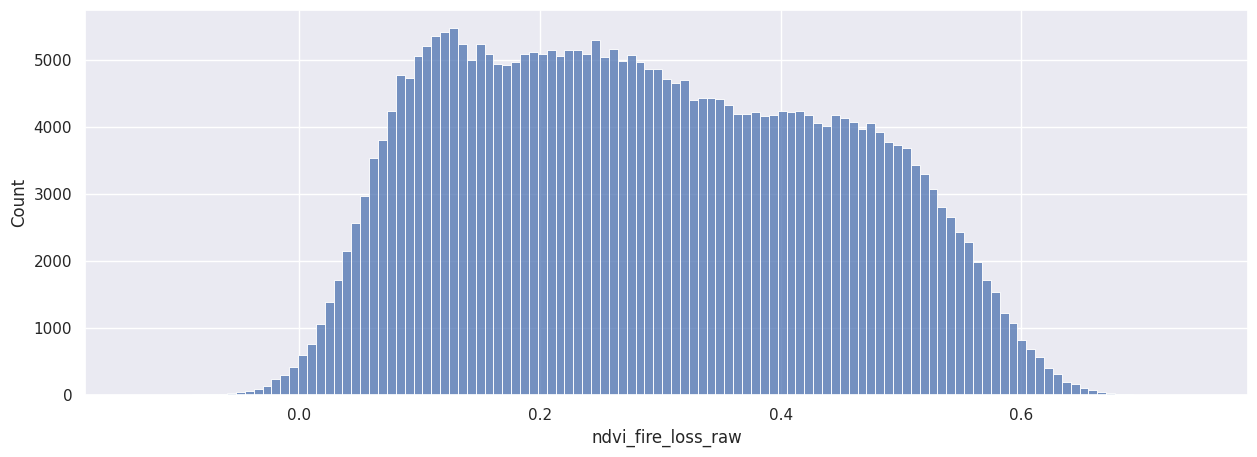

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.histplot(gedi_ndvi, x="ndvi_fire_loss_raw")

<Axes: xlabel='ndvi_fire_loss_rel', ylabel='Count'>

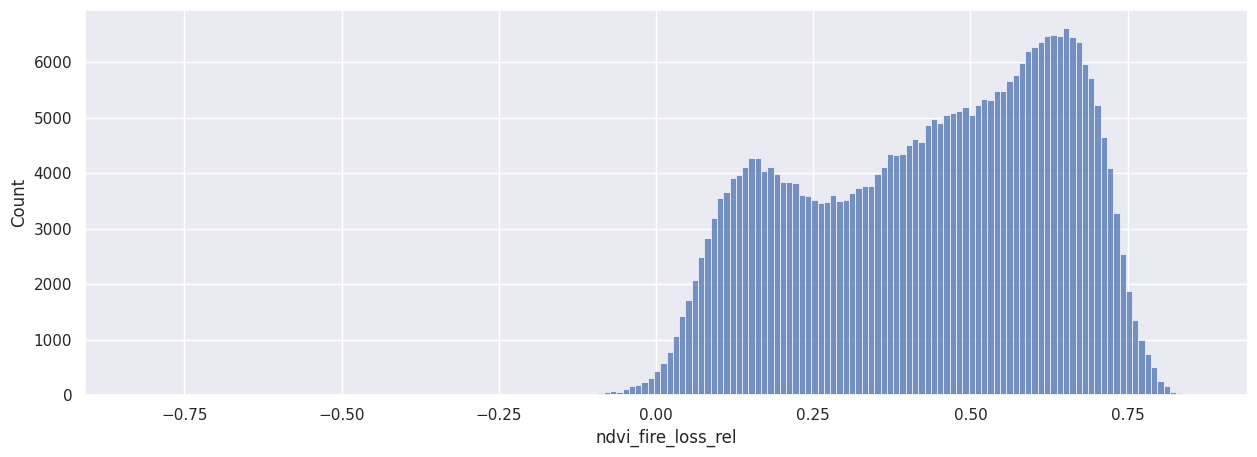

In [84]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.histplot(gedi_ndvi, x="ndvi_fire_loss_rel")

<Axes: xlabel='ndvi_fire_loss_raw', ylabel='Count'>

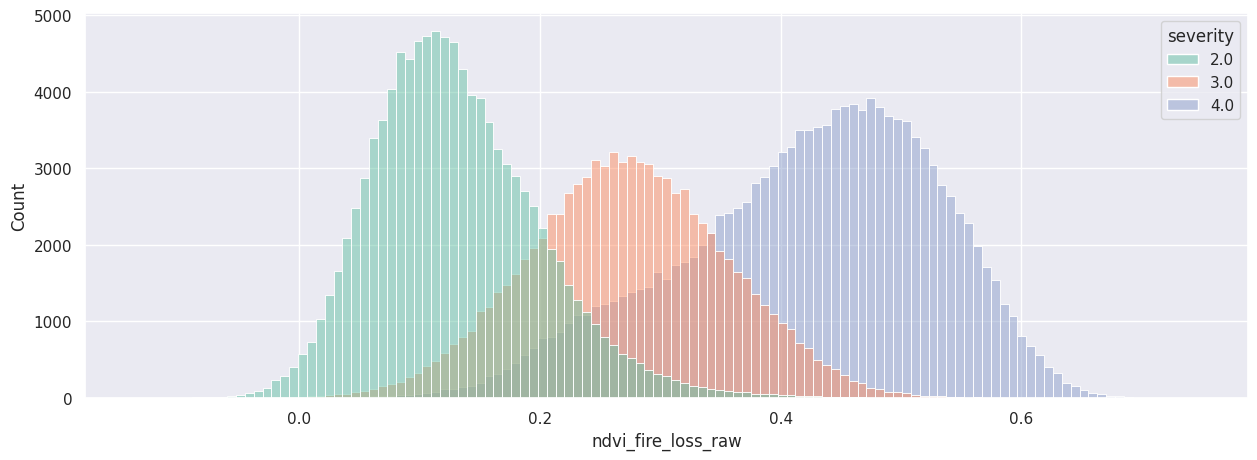

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.histplot(gedi_ndvi, x="ndvi_fire_loss_raw", hue="severity", palette="Set2")

<Axes: xlabel='ndvi_fire_loss_rel', ylabel='Count'>

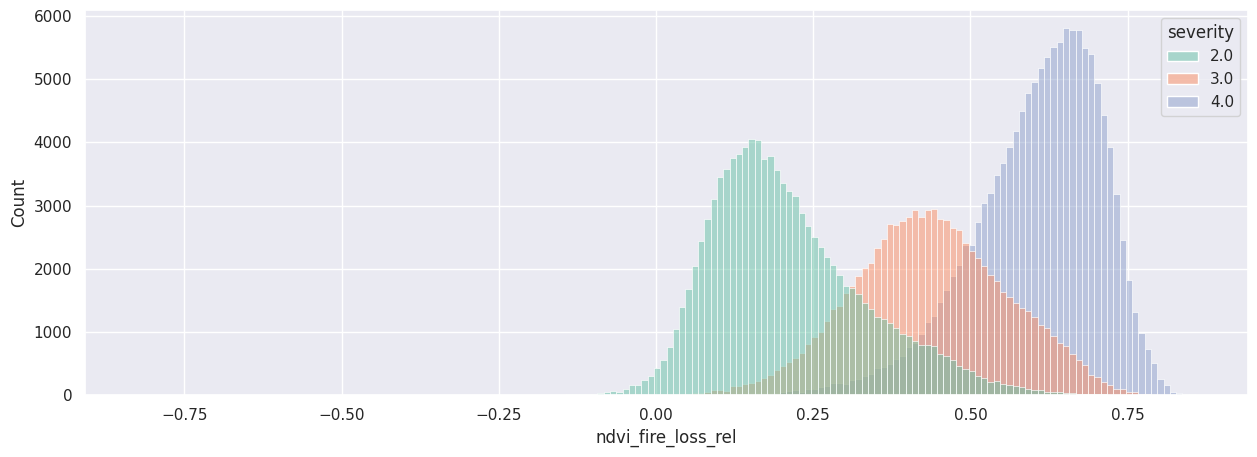

In [85]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.histplot(gedi_ndvi, x="ndvi_fire_loss_rel", hue="severity", palette="Set2")

### NDVI recovery stats

In [10]:
for i in range(1, 35):
    gedi_ndvi[f'{i}_rel'] = gedi_ndvi[f"{i}"] / gedi_ndvi["-1"]

In [11]:
print(gedi_ndvi['1_rel'].mean())
print(gedi_ndvi['5_rel'].mean())
print(gedi_ndvi['10_rel'].mean())
print(gedi_ndvi['15_rel'].mean())
print(gedi_ndvi['20_rel'].mean())
print(gedi_ndvi['25_rel'].mean())
print(gedi_ndvi['30_rel'].mean())
print(gedi_ndvi['34_rel'].mean())

0.5667907973961759
0.737331481235931
0.8483432126935685
0.8976509476723503
0.9651356829888037
1.032472549071511
1.0609927607102938
1.1345775621860472


In [12]:
gedi_ndvi.groupby("severity").mean(numeric_only=True)[['1_rel', '5_rel', '10_rel', '15_rel', '20_rel', '25_rel', '30_rel', '34_rel']]

,1_rel,5_rel,10_rel,15_rel,20_rel,25_rel,30_rel,34_rel
severity,,,,,,,,
2.0,0.790435,0.855620,0.929559,0.951686,0.995331,1.032058,1.073818,1.180371
3.0,0.565790,0.743797,0.863573,0.907070,0.960872,1.023476,1.051132,1.024677
4.0,0.394935,0.658295,0.792957,0.864237,0.949962,1.037679,1.058712,1.020297


In [108]:
gedi_ndvi.groupby("severity").median(numeric_only=True)[['1_rel', '5_rel', '10_rel', '15_rel', '20_rel', '25_rel', '30_rel', '34_rel']]

,1_rel,5_rel,10_rel,15_rel,20_rel,25_rel,30_rel,34_rel
severity,,,,,,,,
2.0,0.811708,0.881321,0.934634,0.965337,1.011070,1.044887,1.062997,1.169258
3.0,0.567169,0.758188,0.873850,0.929067,0.979293,1.043634,1.062986,1.059635
4.0,0.379414,0.671628,0.804425,0.877744,0.965784,1.045395,1.080521,1.046100


In [109]:
gedi_ndvi.groupby("severity").std(numeric_only=True)[['1_rel', '5_rel', '10_rel', '15_rel', '20_rel', '25_rel', '30_rel', '34_rel']]

,1_rel,5_rel,10_rel,15_rel,20_rel,25_rel,30_rel,34_rel
severity,,,,,,,,
2.0,0.123247,0.129592,0.124458,0.134445,0.130742,0.162266,0.126643,0.120539
3.0,0.122235,0.158539,0.144595,0.157567,0.150818,0.164822,0.144359,0.172278
4.0,0.102853,0.185843,0.168898,0.147485,0.129543,0.137065,0.121807,0.124001


In [103]:
print(gedi_ndvi['5_rel'].median())
print(gedi_ndvi['10_rel'].median())
print(gedi_ndvi['15_rel'].median())
print(gedi_ndvi['20_rel'].median())
print(gedi_ndvi['25_rel'].median())
print(gedi_ndvi['30_rel'].median())
print(gedi_ndvi['34_rel'].median())

0.7628300822102237
0.8678192687154989
0.915036969260546
0.9807389384803745
1.0447979159169976
1.0692825929808456
1.1415032664802074


In [68]:
save_pickle("/maps/fire-regen/data/gedi_ndvi_timeseries_jun_25.pkl", gedi_ndvi)

In [2]:
gedi_ndvi = load_pickle("/maps/fire-regen/data/gedi_ndvi_timeseries_jun_25.pkl")

In [3]:
new_df = pd.melt(gedi_ndvi, id_vars=["severity", "burn_year"], value_vars=[str(x) for x in range(-10, 35)])
new_df

,severity,burn_year,variable,value
0,2.0,1985.0,-10,NaN
1,2.0,1985.0,-10,NaN
2,2.0,1985.0,-10,NaN
3,2.0,1985.0,-10,NaN
4,2.0,1985.0,-10,NaN
...,...,...,...,...
18217255,2.0,2020.0,34,NaN
18217256,3.0,2020.0,34,NaN
18217257,2.0,2020.0,34,NaN
18217258,4.0,2020.0,34,NaN


/maps-priv/maps/fire-regen/fire-regen-env/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/maps-priv/maps/fire-regen/fire-regen-env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1556: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


<Axes: xlabel='variable', ylabel='value'>

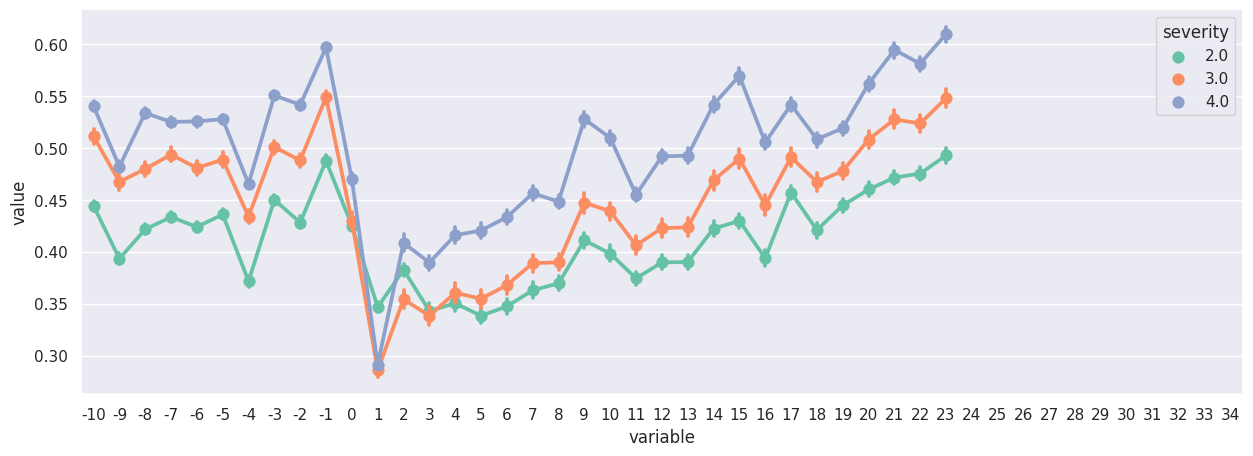

In [75]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.pointplot(new_df[new_df.burn_year == 1996], x="variable", y="value", hue="severity", ax=ax, palette="Set2")

In [7]:
pd.DataFrame(ndvis)

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
0,0.568421,0.584201,0.513520,0.522505,0.434219,0.565334,0.526846,0.543040,0.495273,0.532913,...,0.662150,0.654849,0.595411,0.644008,0.582611,0.636357,0.632610,0.675366,0.664085,0.718946
1,0.587675,0.601839,0.467035,0.478439,0.436786,0.522513,0.506215,0.505793,0.473053,0.517666,...,0.693751,0.694441,0.632157,0.694591,0.638106,0.677997,0.685623,0.718585,0.691538,0.748763
2,0.572759,0.587323,0.516330,0.513258,0.432634,0.540689,0.520260,0.537109,0.480233,0.525431,...,0.696997,0.682389,0.627655,0.665395,0.581009,0.649598,0.642705,0.692194,0.675550,0.734887
3,0.587906,0.599558,0.527842,0.532940,0.457673,0.571323,0.547304,0.557281,0.512940,0.545986,...,0.700114,0.691291,0.643578,0.681679,0.608909,0.685482,0.681916,0.718076,0.705058,0.759061
4,0.506719,0.523731,0.462426,0.443350,0.379263,0.494780,0.456557,0.480287,0.412907,0.462395,...,0.571775,0.589922,0.496090,0.529609,0.494940,0.538704,0.525096,0.575220,0.549411,0.628559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405942,0.410404,0.410874,0.419825,0.403790,0.385442,0.407834,0.391221,0.388948,0.372987,0.389936,...,0.423073,0.438944,0.397288,0.454312,0.442310,0.409898,0.418196,0.449566,0.434038,0.451418
405943,0.500904,0.482579,0.493320,0.461966,0.428437,0.464373,0.431232,0.436636,0.420820,0.440889,...,0.512030,0.540078,0.476451,0.525902,0.511935,0.475957,0.526999,0.561465,0.533854,0.563058
405944,0.432730,0.437270,0.448759,0.436975,0.395881,0.429151,0.411462,0.406100,0.382903,0.420219,...,0.448149,0.474085,0.430515,0.492061,0.479251,0.464917,0.479695,0.513713,0.491255,0.502332
405945,0.387195,0.356102,0.402174,0.375432,0.370330,0.371367,0.372175,0.365592,0.329520,0.386371,...,0.423473,0.427977,0.389965,0.451721,0.431205,0.427321,0.449603,0.460166,0.439250,0.462731


In [5]:
# year 35
year_35 = gedi_recovery_2x2[gedi_recovery_2x2.burn_year == 1985]
ndvi_35 = ndvis[year_35.index, :]

NameError: name 'gedi_recovery_2x2' is not defined

In [59]:
def get_df(array):
    all_dfs = []
    for i in range(0, 36):
        new_df = pd.DataFrame(ndvi_35[:, i], columns=["ndvi"])
        new_df['time'] = i
        new_df['severity'] = year_35.severity.values
        all_dfs.append(new_df)
    return pd.concat(all_dfs)

<Axes: xlabel='time', ylabel='ndvi'>

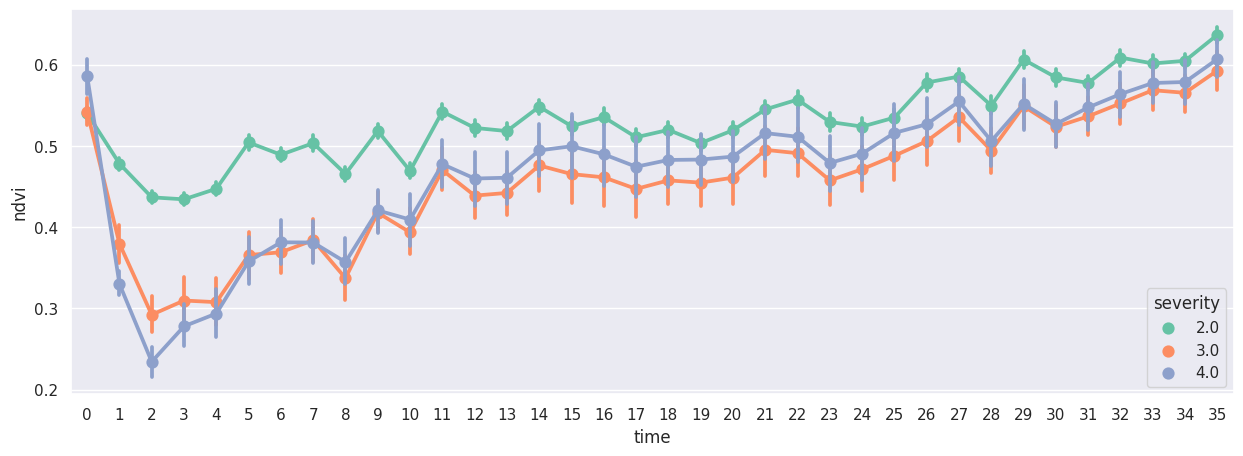

In [72]:
# year 35
year_35 = gedi_recovery_2x2[(gedi_recovery_2x2.burn_year == 1985) & (gedi_recovery_2x2.pft_class==1)]
ndvi_35 = ndvis[year_35.index, :]
lala = get_df(ndvi_35)
lala = lala.reset_index()
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.pointplot(lala, x="time", y="ndvi", hue="severity", ax=ax, palette="Set2")

<Axes: xlabel='time', ylabel='ndvi'>

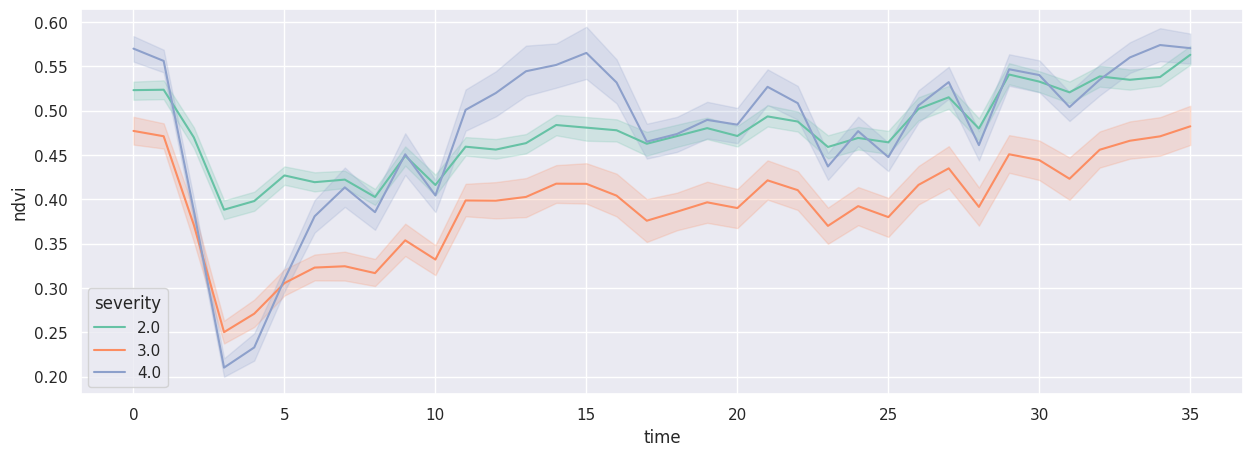

In [68]:
# year 35
year_35 = gedi_recovery_2x2[(gedi_recovery_2x2.burn_year == 1986) & (gedi_recovery_2x2.pft_class==1)]
ndvi_35 = ndvis[year_35.index, :]
lala = get_df(ndvi_35)
lala = lala.reset_index()
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.lineplot(lala, x="time", y="ndvi", hue="severity", ax=ax, palette="Set2")

<Axes: xlabel='time', ylabel='ndvi'>

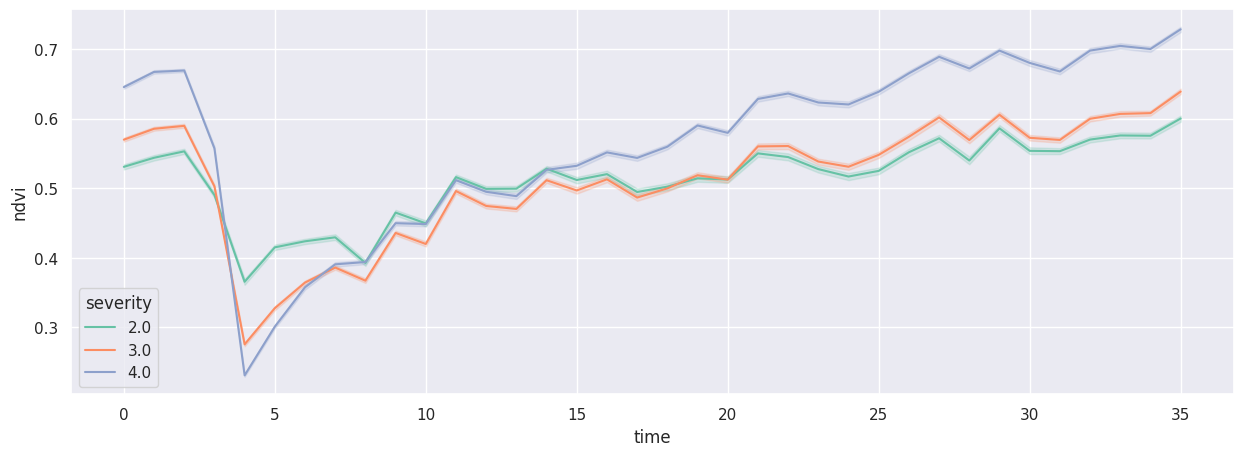

In [69]:
# year 35
year_35 = gedi_recovery_2x2[(gedi_recovery_2x2.burn_year == 1987) & (gedi_recovery_2x2.pft_class==1)]
ndvi_35 = ndvis[year_35.index, :]
lala = get_df(ndvi_35)
lala = lala.reset_index()
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.lineplot(lala, x="time", y="ndvi", hue="severity", ax=ax, palette="Set2")

<Axes: xlabel='time', ylabel='ndvi'>

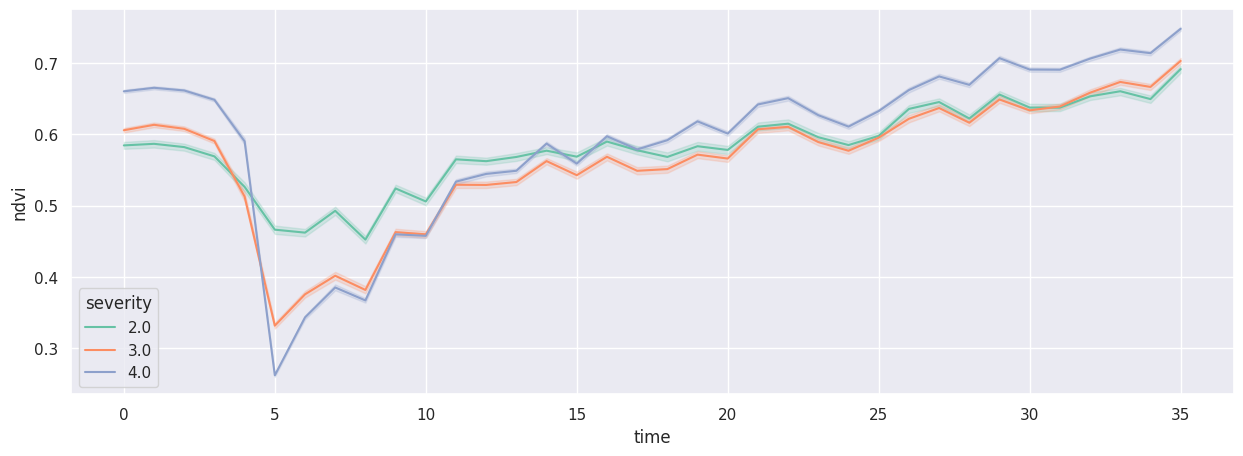

In [70]:
# year 35
year_35 = gedi_recovery_2x2[(gedi_recovery_2x2.burn_year == 1988) & (gedi_recovery_2x2.pft_class==1)]
ndvi_35 = ndvis[year_35.index, :]
lala = get_df(ndvi_35)
lala = lala.reset_index()
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.lineplot(lala, x="time", y="ndvi", hue="severity", ax=ax, palette="Set2")

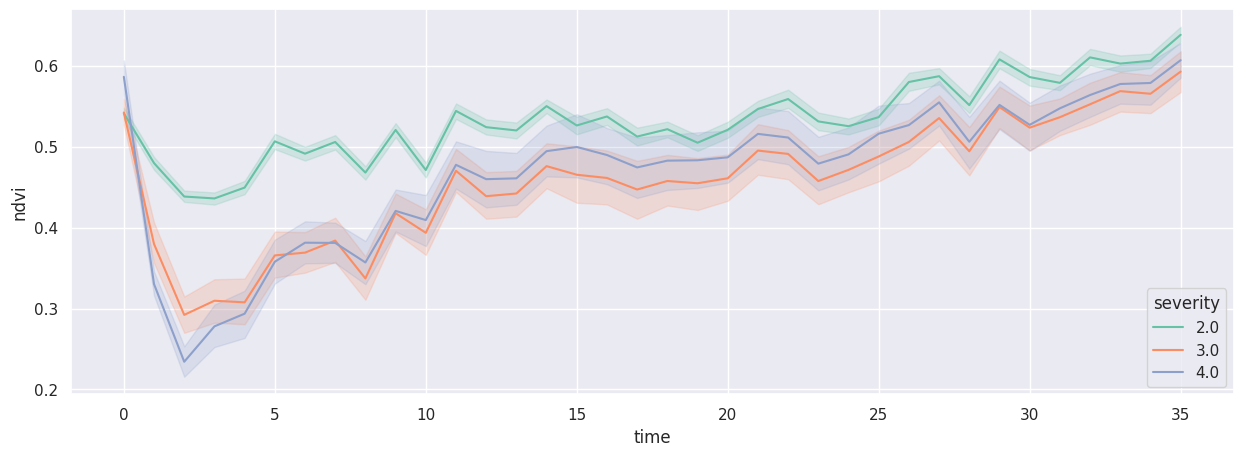

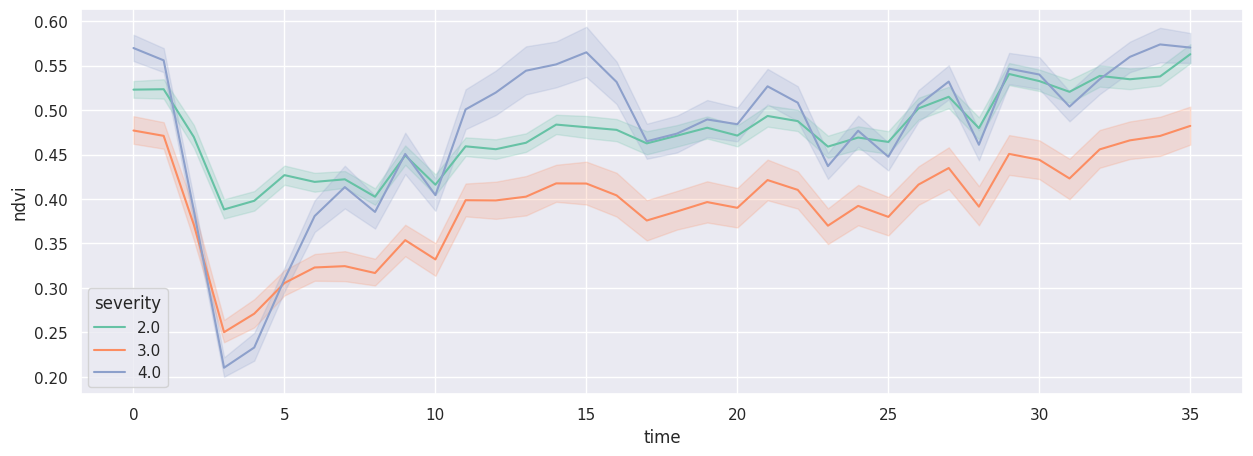

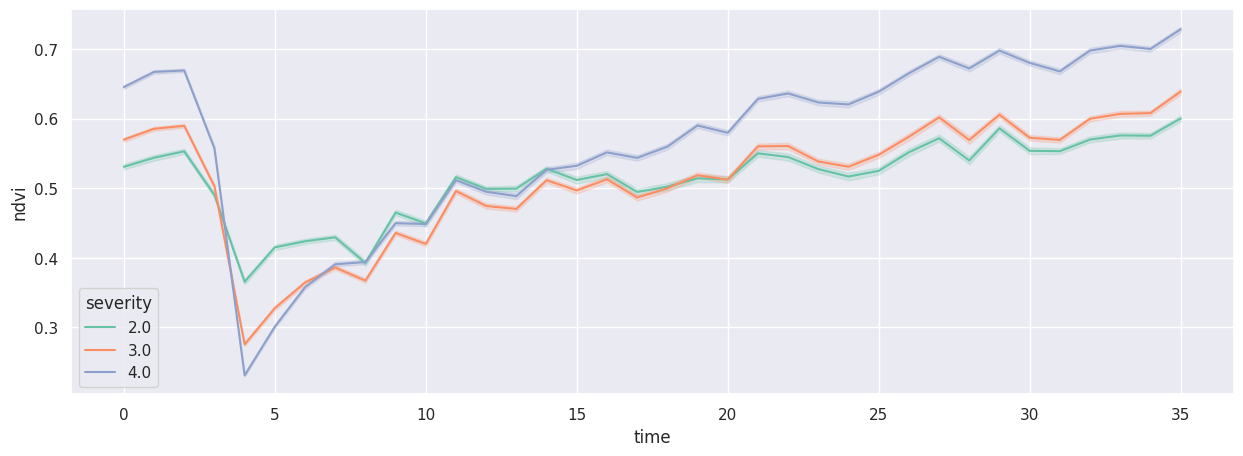

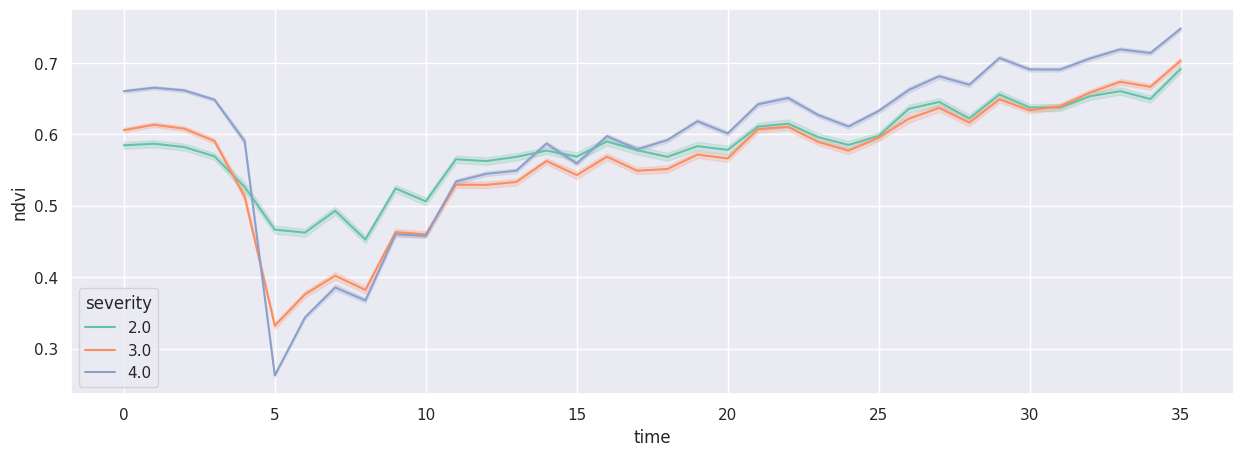

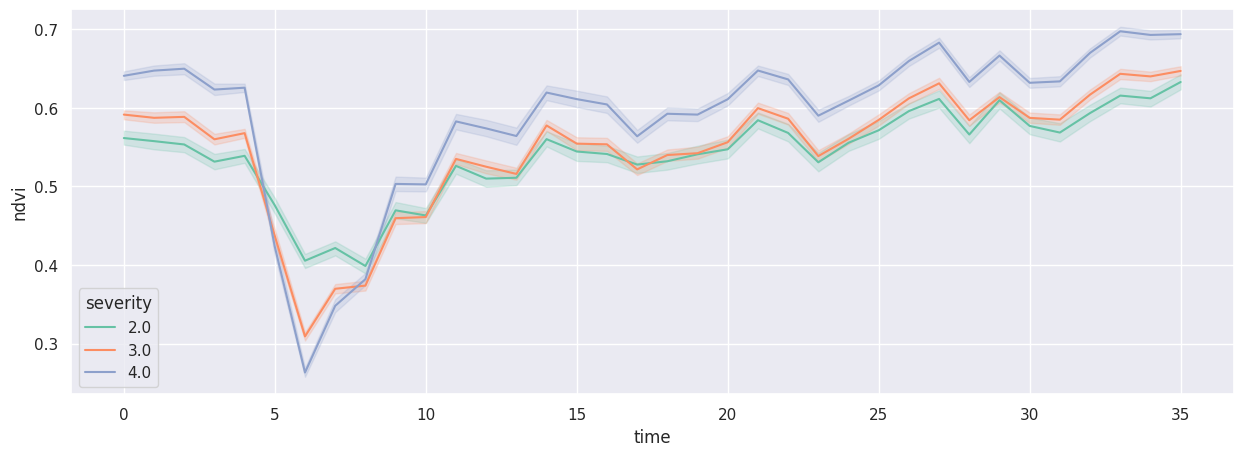

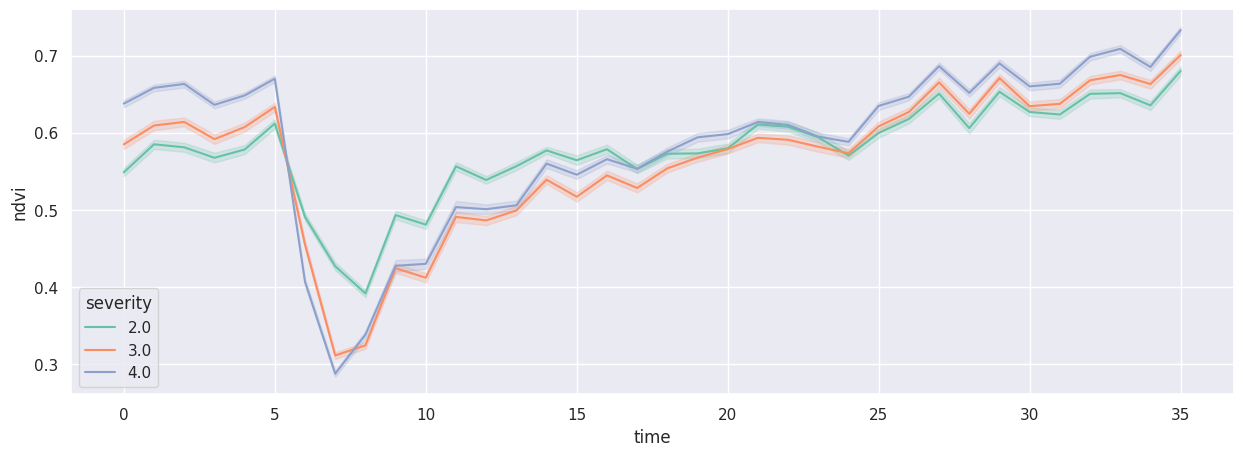

In [72]:
# year 35
for year in range(1985, 1991):
    year_35 = gedi_recovery_2x2[(gedi_recovery_2x2.burn_year == year) & (gedi_recovery_2x2.pft_class==1)]
    ndvi_35 = ndvis[year_35.index, :]
    lala = get_df(ndvi_35)
    lala = lala.reset_index()
    fig, ax = plt.subplots(1, 1, figsize=(15, 5))
    sns.lineplot(lala, x="time", y="ndvi", hue="severity", ax=ax, palette="Set2")

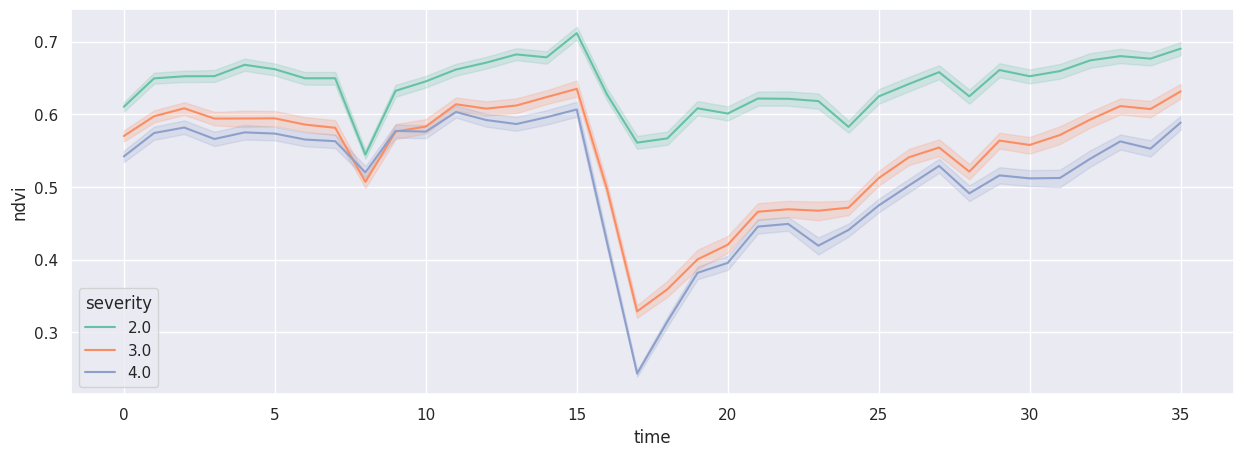

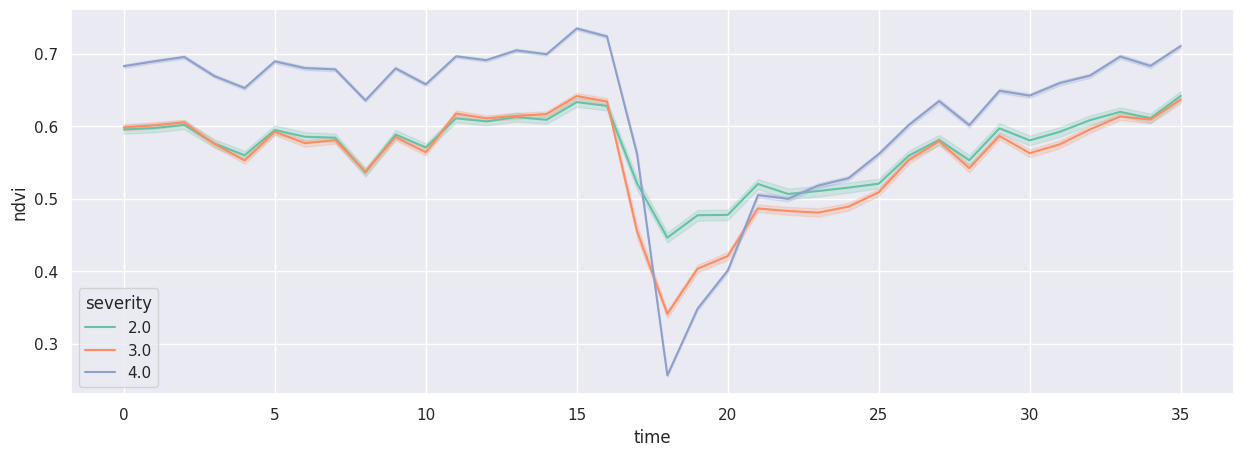

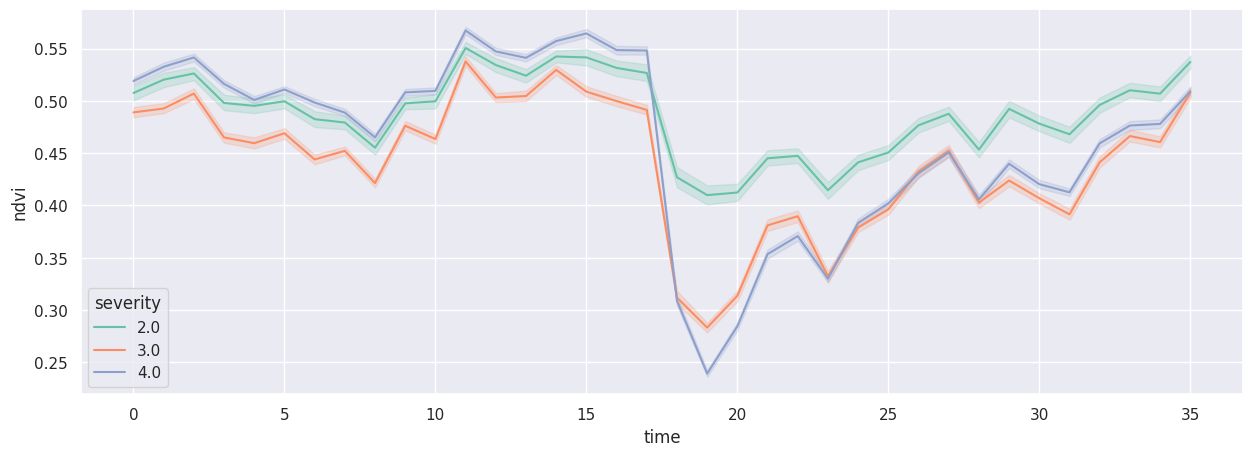

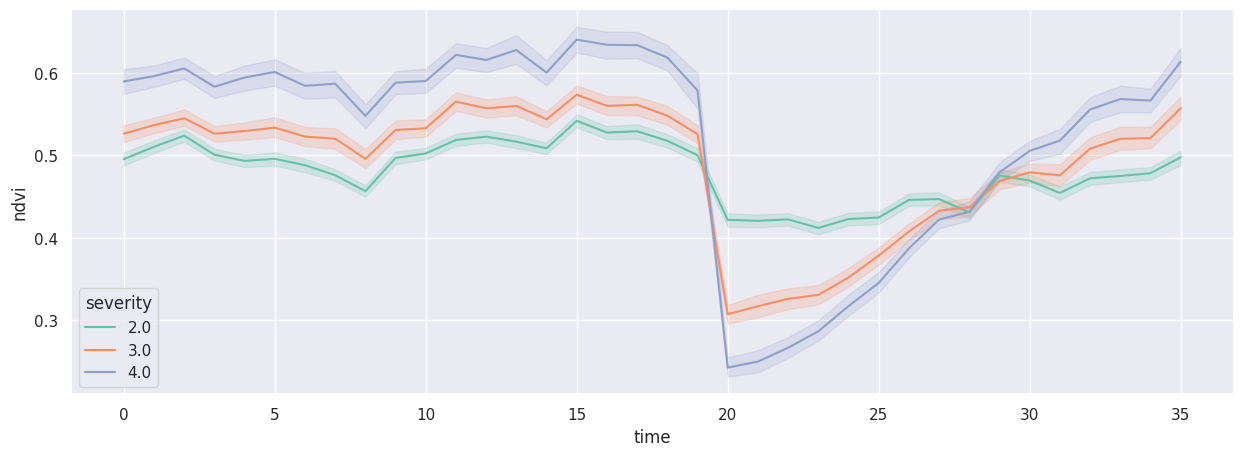

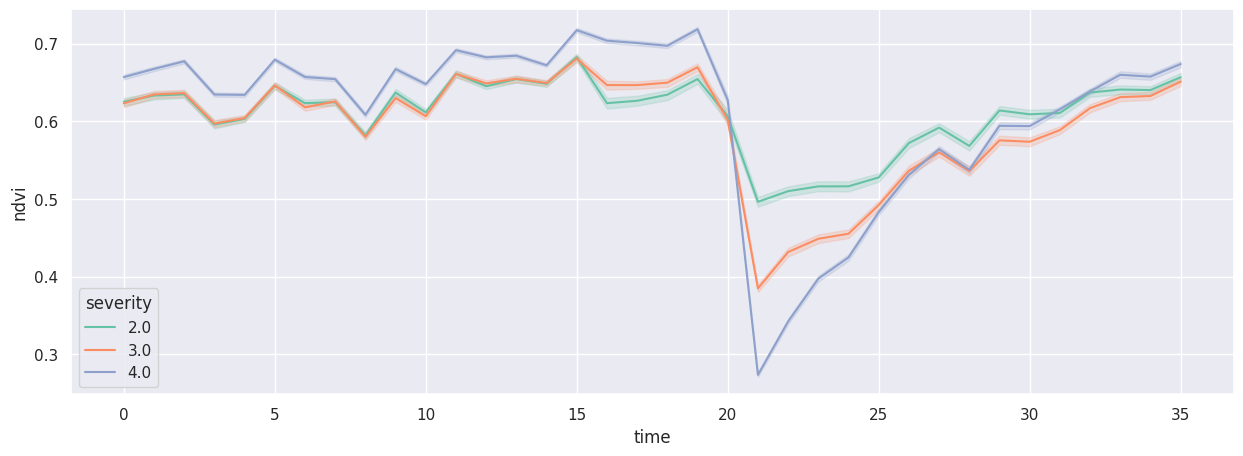

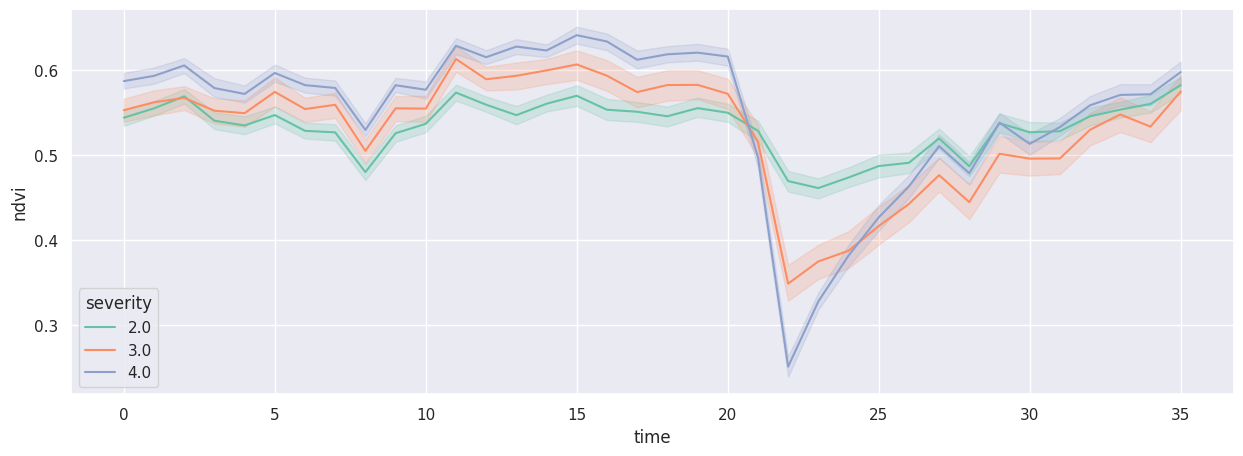

In [73]:
# year 35
for year in range(2000, 2006):
    year_35 = gedi_recovery_2x2[(gedi_recovery_2x2.burn_year == year) & (gedi_recovery_2x2.pft_class==1)]
    ndvi_35 = ndvis[year_35.index, :]
    lala = get_df(ndvi_35)
    lala = lala.reset_index()
    fig, ax = plt.subplots(1, 1, figsize=(15, 5))
    sns.lineplot(lala, x="time", y="ndvi", hue="severity", ax=ax, palette="Set2")

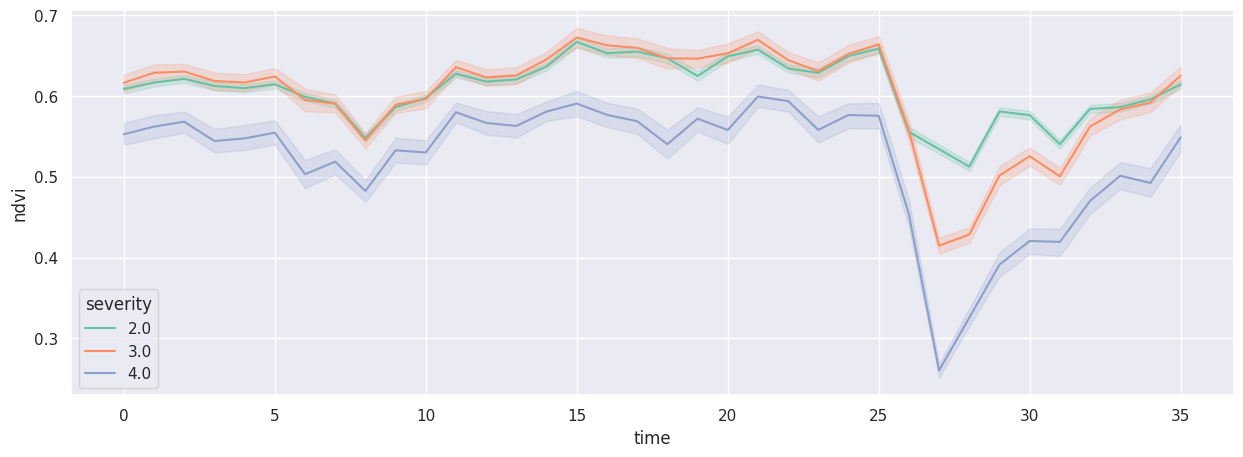

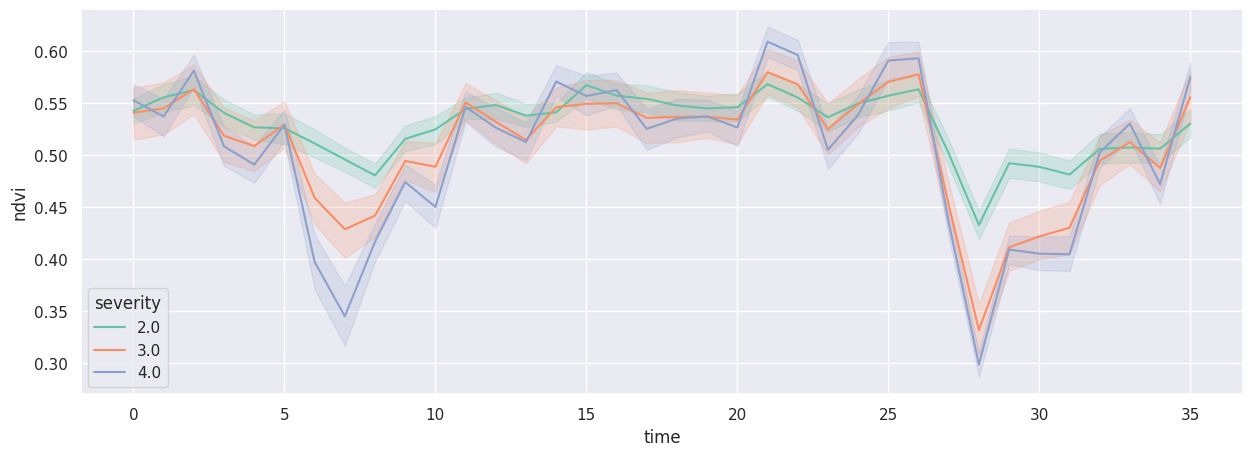

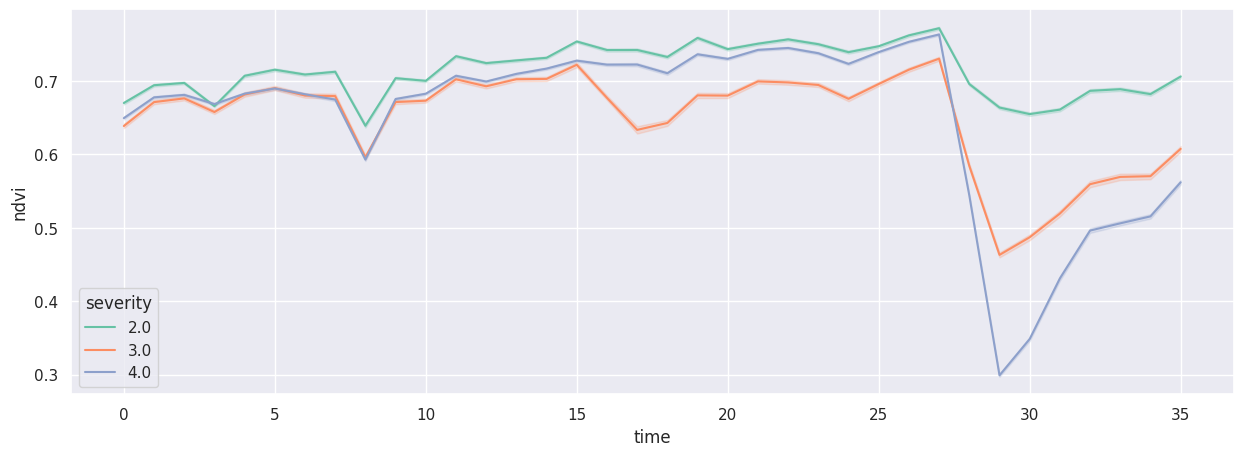

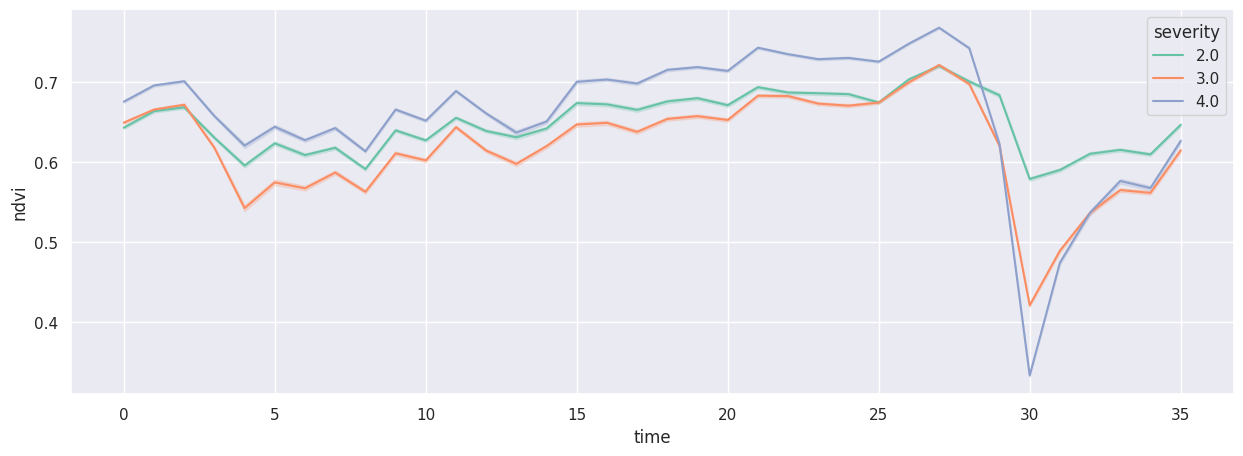

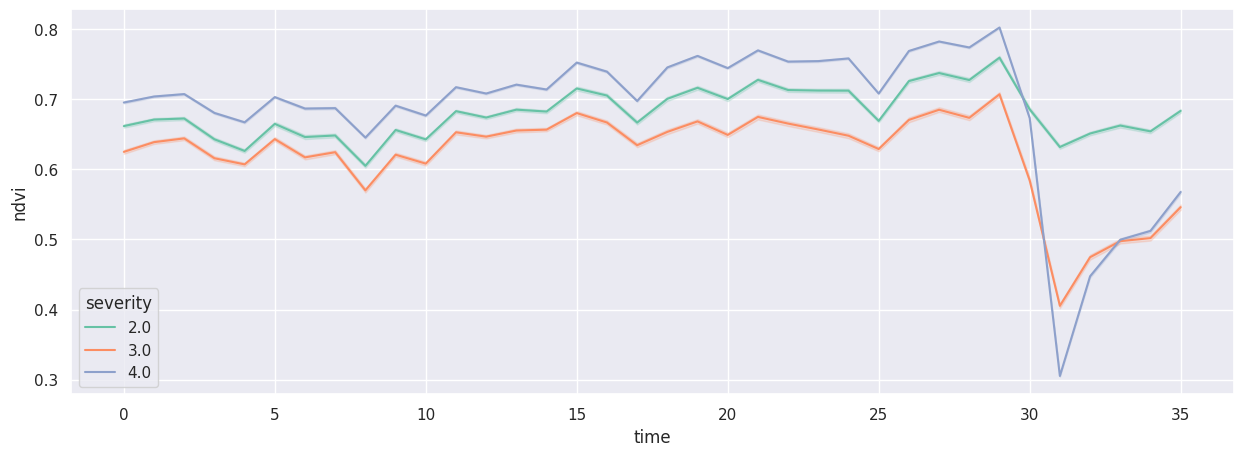

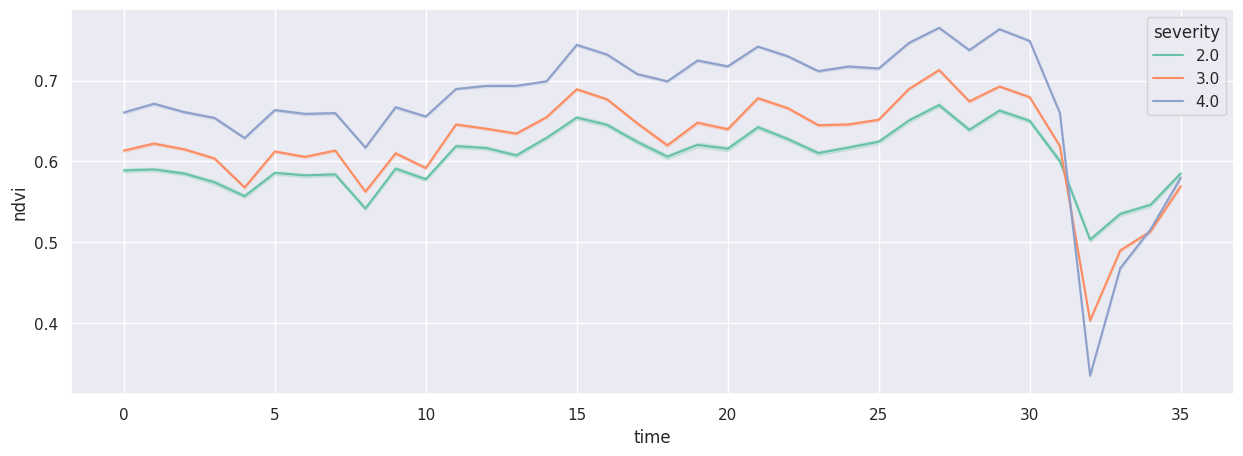

In [99]:
# year 35
for year in range(2010, 2016):
    year_35 = gedi_recovery_2x2[(gedi_recovery_2x2.burn_year == year) & (gedi_recovery_2x2.pft_class==1)]
    ndvi_35 = ndvis[year_35.index, :]
    lala = get_df(ndvi_35)
    lala = lala.reset_index()
    fig, ax = plt.subplots(1, 1, figsize=(15, 5))
    sns.lineplot(lala, x="time", y="ndvi", hue="severity", ax=ax, palette="Set2")

### Time for space substitution using NDVI

In [74]:
# attach the latest NDVI to all gedi shots
gedi_recovery_2x2["latest_ndvi"] = ndvis[:, 35]

<Axes: xlabel='time_since_burn', ylabel='latest_ndvi'>

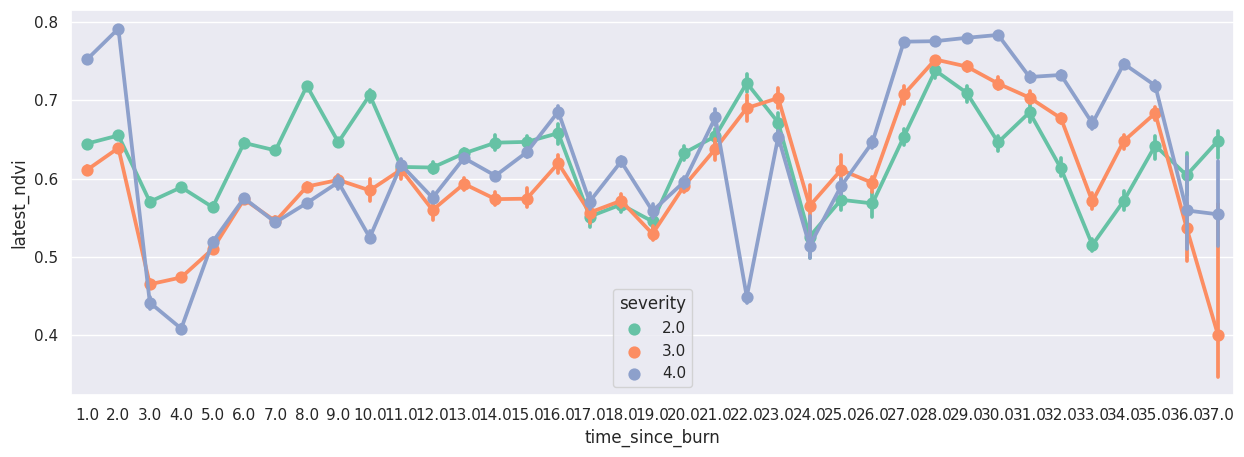

In [141]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.pointplot(gedi_recovery_2x2, x="time_since_burn", y="latest_ndvi", hue="severity", ax=ax, palette="Set2", estimator="median")

<Axes: xlabel='time_since_burn', ylabel='agbd'>

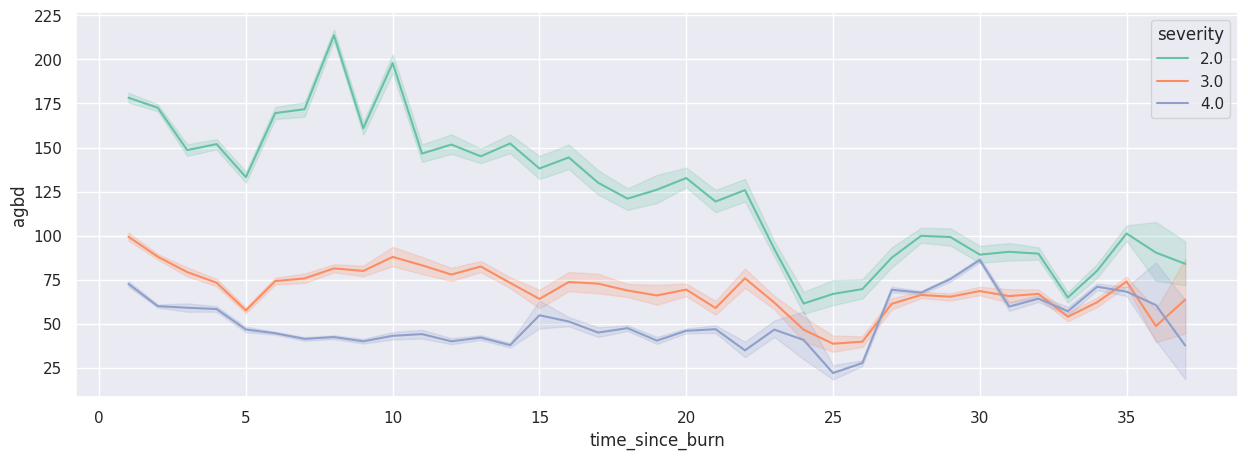

In [77]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.lineplot(gedi_recovery_2x2, x="time_since_burn", y="agbd", hue="severity", ax=ax, palette="Set2")

(0.0, 1000.0)

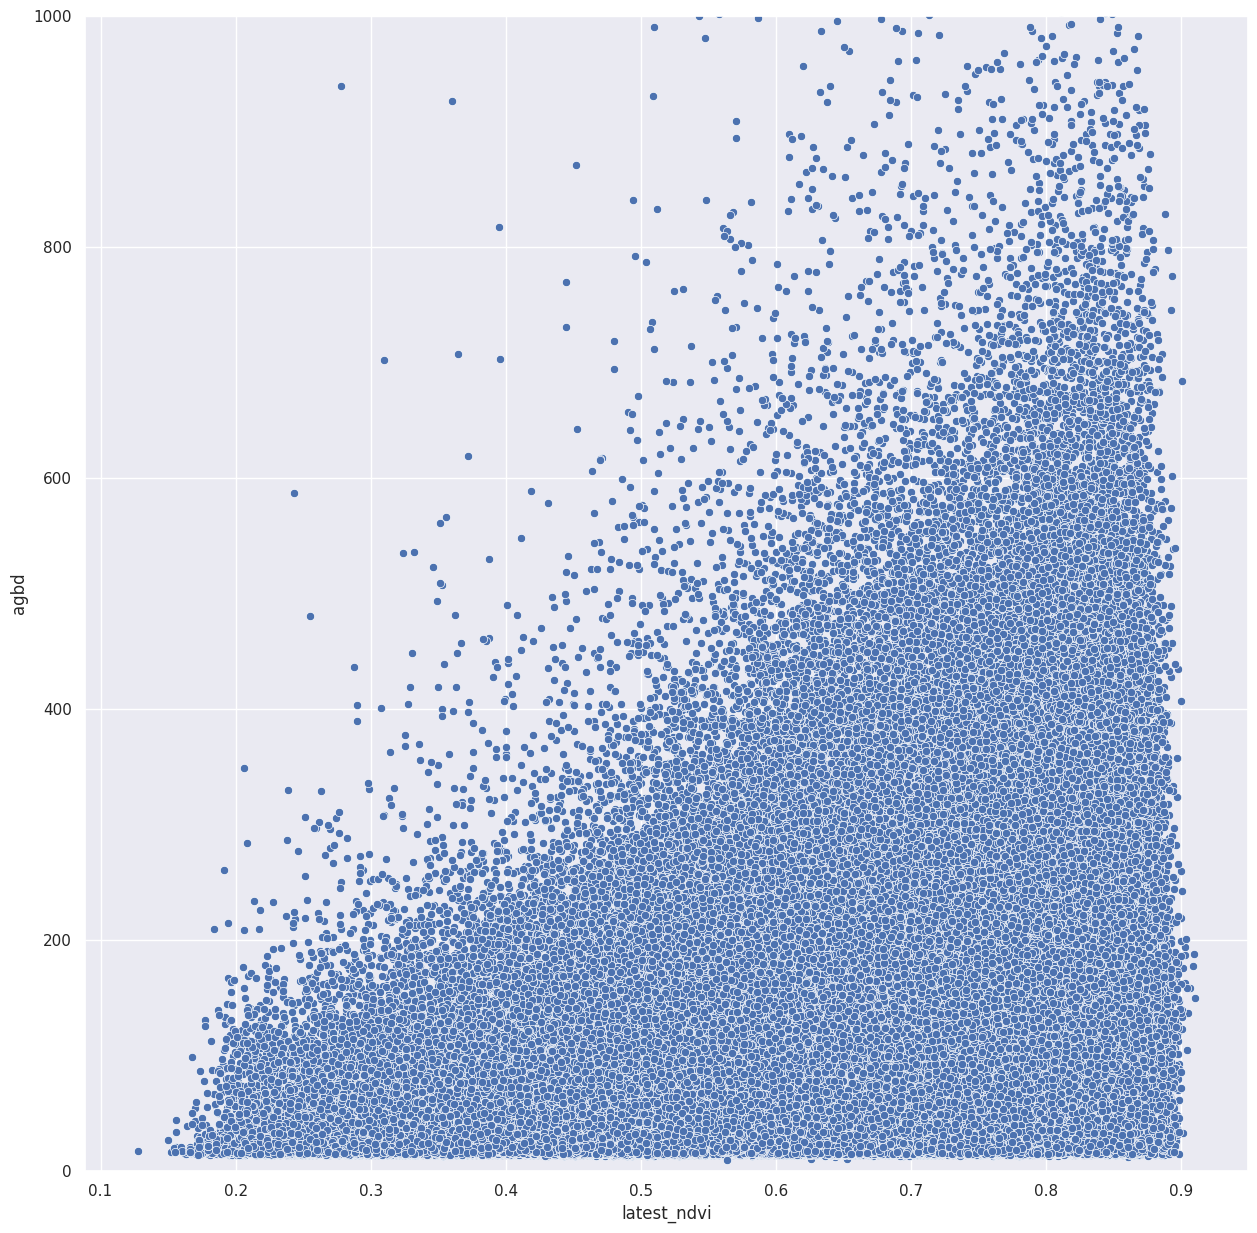

In [80]:
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
sns.scatterplot(gedi_recovery_2x2[gedi_recovery_2x2.pft_class==1], x="latest_ndvi", y='agbd')
ax.set_ylim((0, 1000))

### Perfect counterfactual

In [ ]:
def get_df(array):
    all_dfs = []
    for i in range(0, 36):
        new_df = pd.DataFrame(ndvi_35[:, i], columns=["ndvi"])
        new_df['time'] = i
        new_df['severity'] = year_35.severity.values
        all_dfs.append(new_df)
    return pd.concat(all_dfs)

lala = get_df(ndvi_35)
lala = lala.reset_index()

In [ ]:
# year 35
year_35 = gedi_recovery_2x2[(gedi_recovery_2x2.burn_year == 1985) & (gedi_recovery_2x2.pft_class==1)]
ndvi_35 = ndvis[year_35.index, :]
lala = get_df(ndvi_35)
lala = lala.reset_index()
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.lineplot(lala, x="time", y="ndvi", hue="severity", ax=ax, palette="Set2")

In [ ]:
# attach the latest NDVI to all gedi shots
gedi_recovery_2x2["latest_ndvi"] = ndvis[:, 35]

In [83]:
control_ndvi = np.empty(gedi_recovery_2x2.shape[0])

In [86]:
control_ndvi = np.empty(gedi_recovery_2x2.shape[0])
control_index = (gedi_recovery_2x2.burn_year - 1985).values.astype(int)
for i in range(gedi_recovery_2x2.shape[0]):
    control_ndvi[i] = ndvis[i, control_index[i]]
gedi_recovery_2x2["control_ndvi"] = control_ndvi

In [88]:
gedi_recovery_2x2["control_ndvi"] = control_ndvi

In [89]:
gedi_recovery_2x2["rel_ndvi"] = gedi_recovery_2x2.latest_ndvi / gedi_recovery_2x2.control_ndvi

<Axes: xlabel='time_since_burn', ylabel='rel_ndvi'>

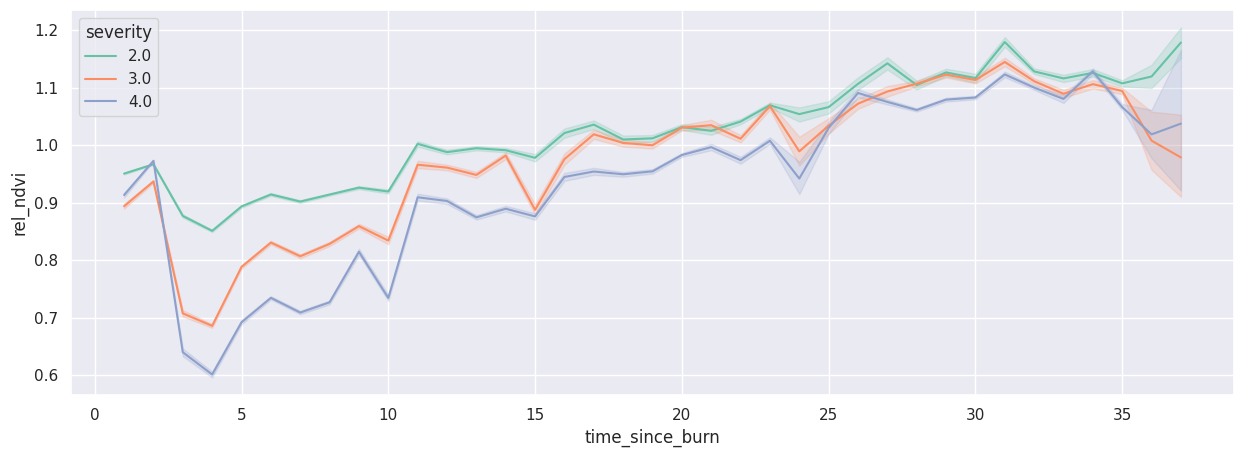

In [90]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.lineplot(gedi_recovery_2x2, x="time_since_burn", y="rel_ndvi", hue="severity", ax=ax, palette="Set2")

<Axes: xlabel='time_since_burn', ylabel='control_ndvi'>

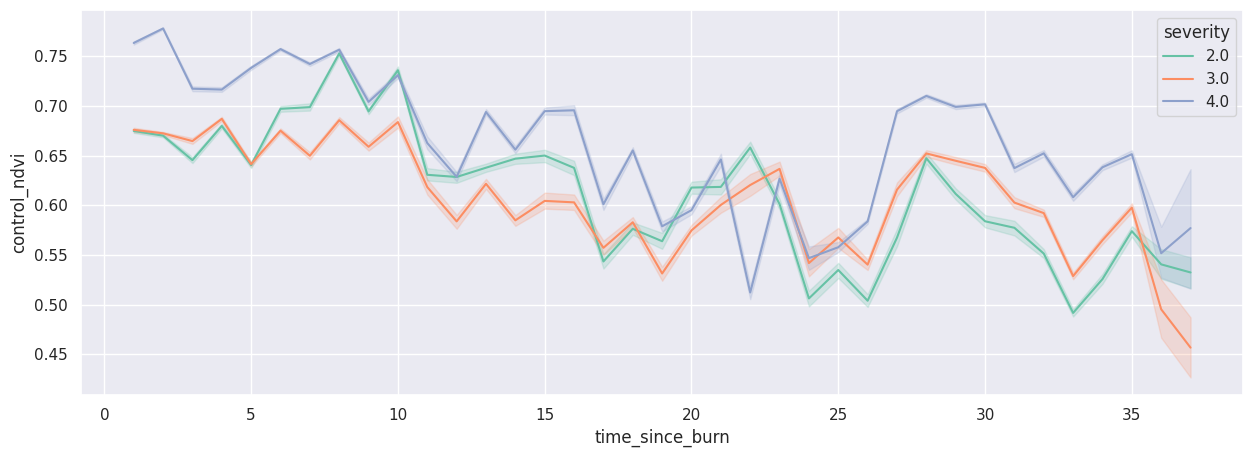

In [91]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.lineplot(gedi_recovery_2x2, x="time_since_burn", y="control_ndvi", hue="severity", ax=ax, palette="Set2")

<Axes: xlabel='time_since_burn', ylabel='agbd_control'>

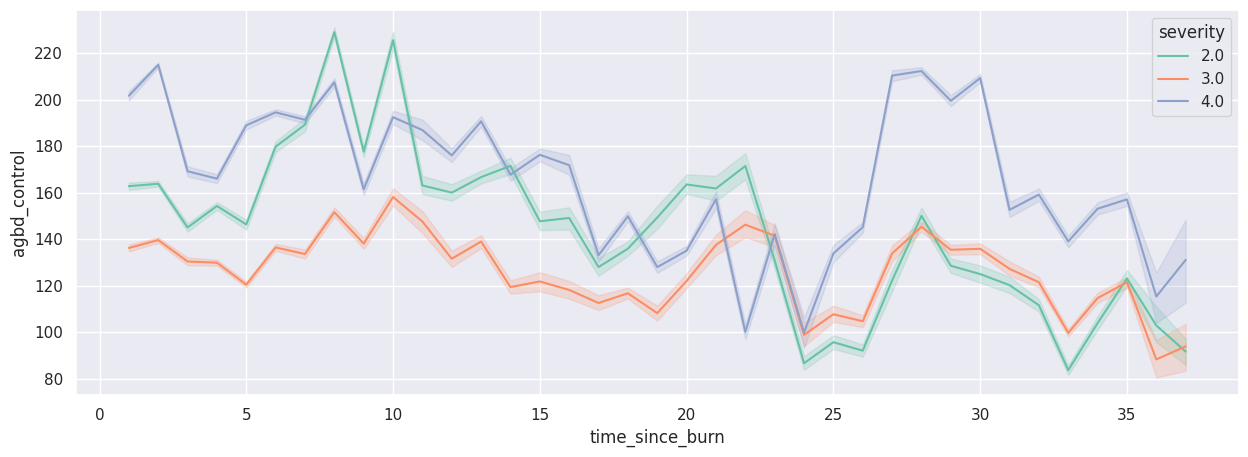

In [93]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.lineplot(gedi_recovery_2x2, x="time_since_burn", y="agbd_control", hue="severity", ax=ax, palette="Set2")

In [94]:
gedi_recovery_2x2["agbd_div_ndvi"] = gedi_recovery_2x2.agbd / gedi_recovery_2x2.control_ndvi
gedi_recovery_2x2["ndvi_div_agbd"] = gedi_recovery_2x2.control_ndvi / gedi_recovery_2x2.agbd

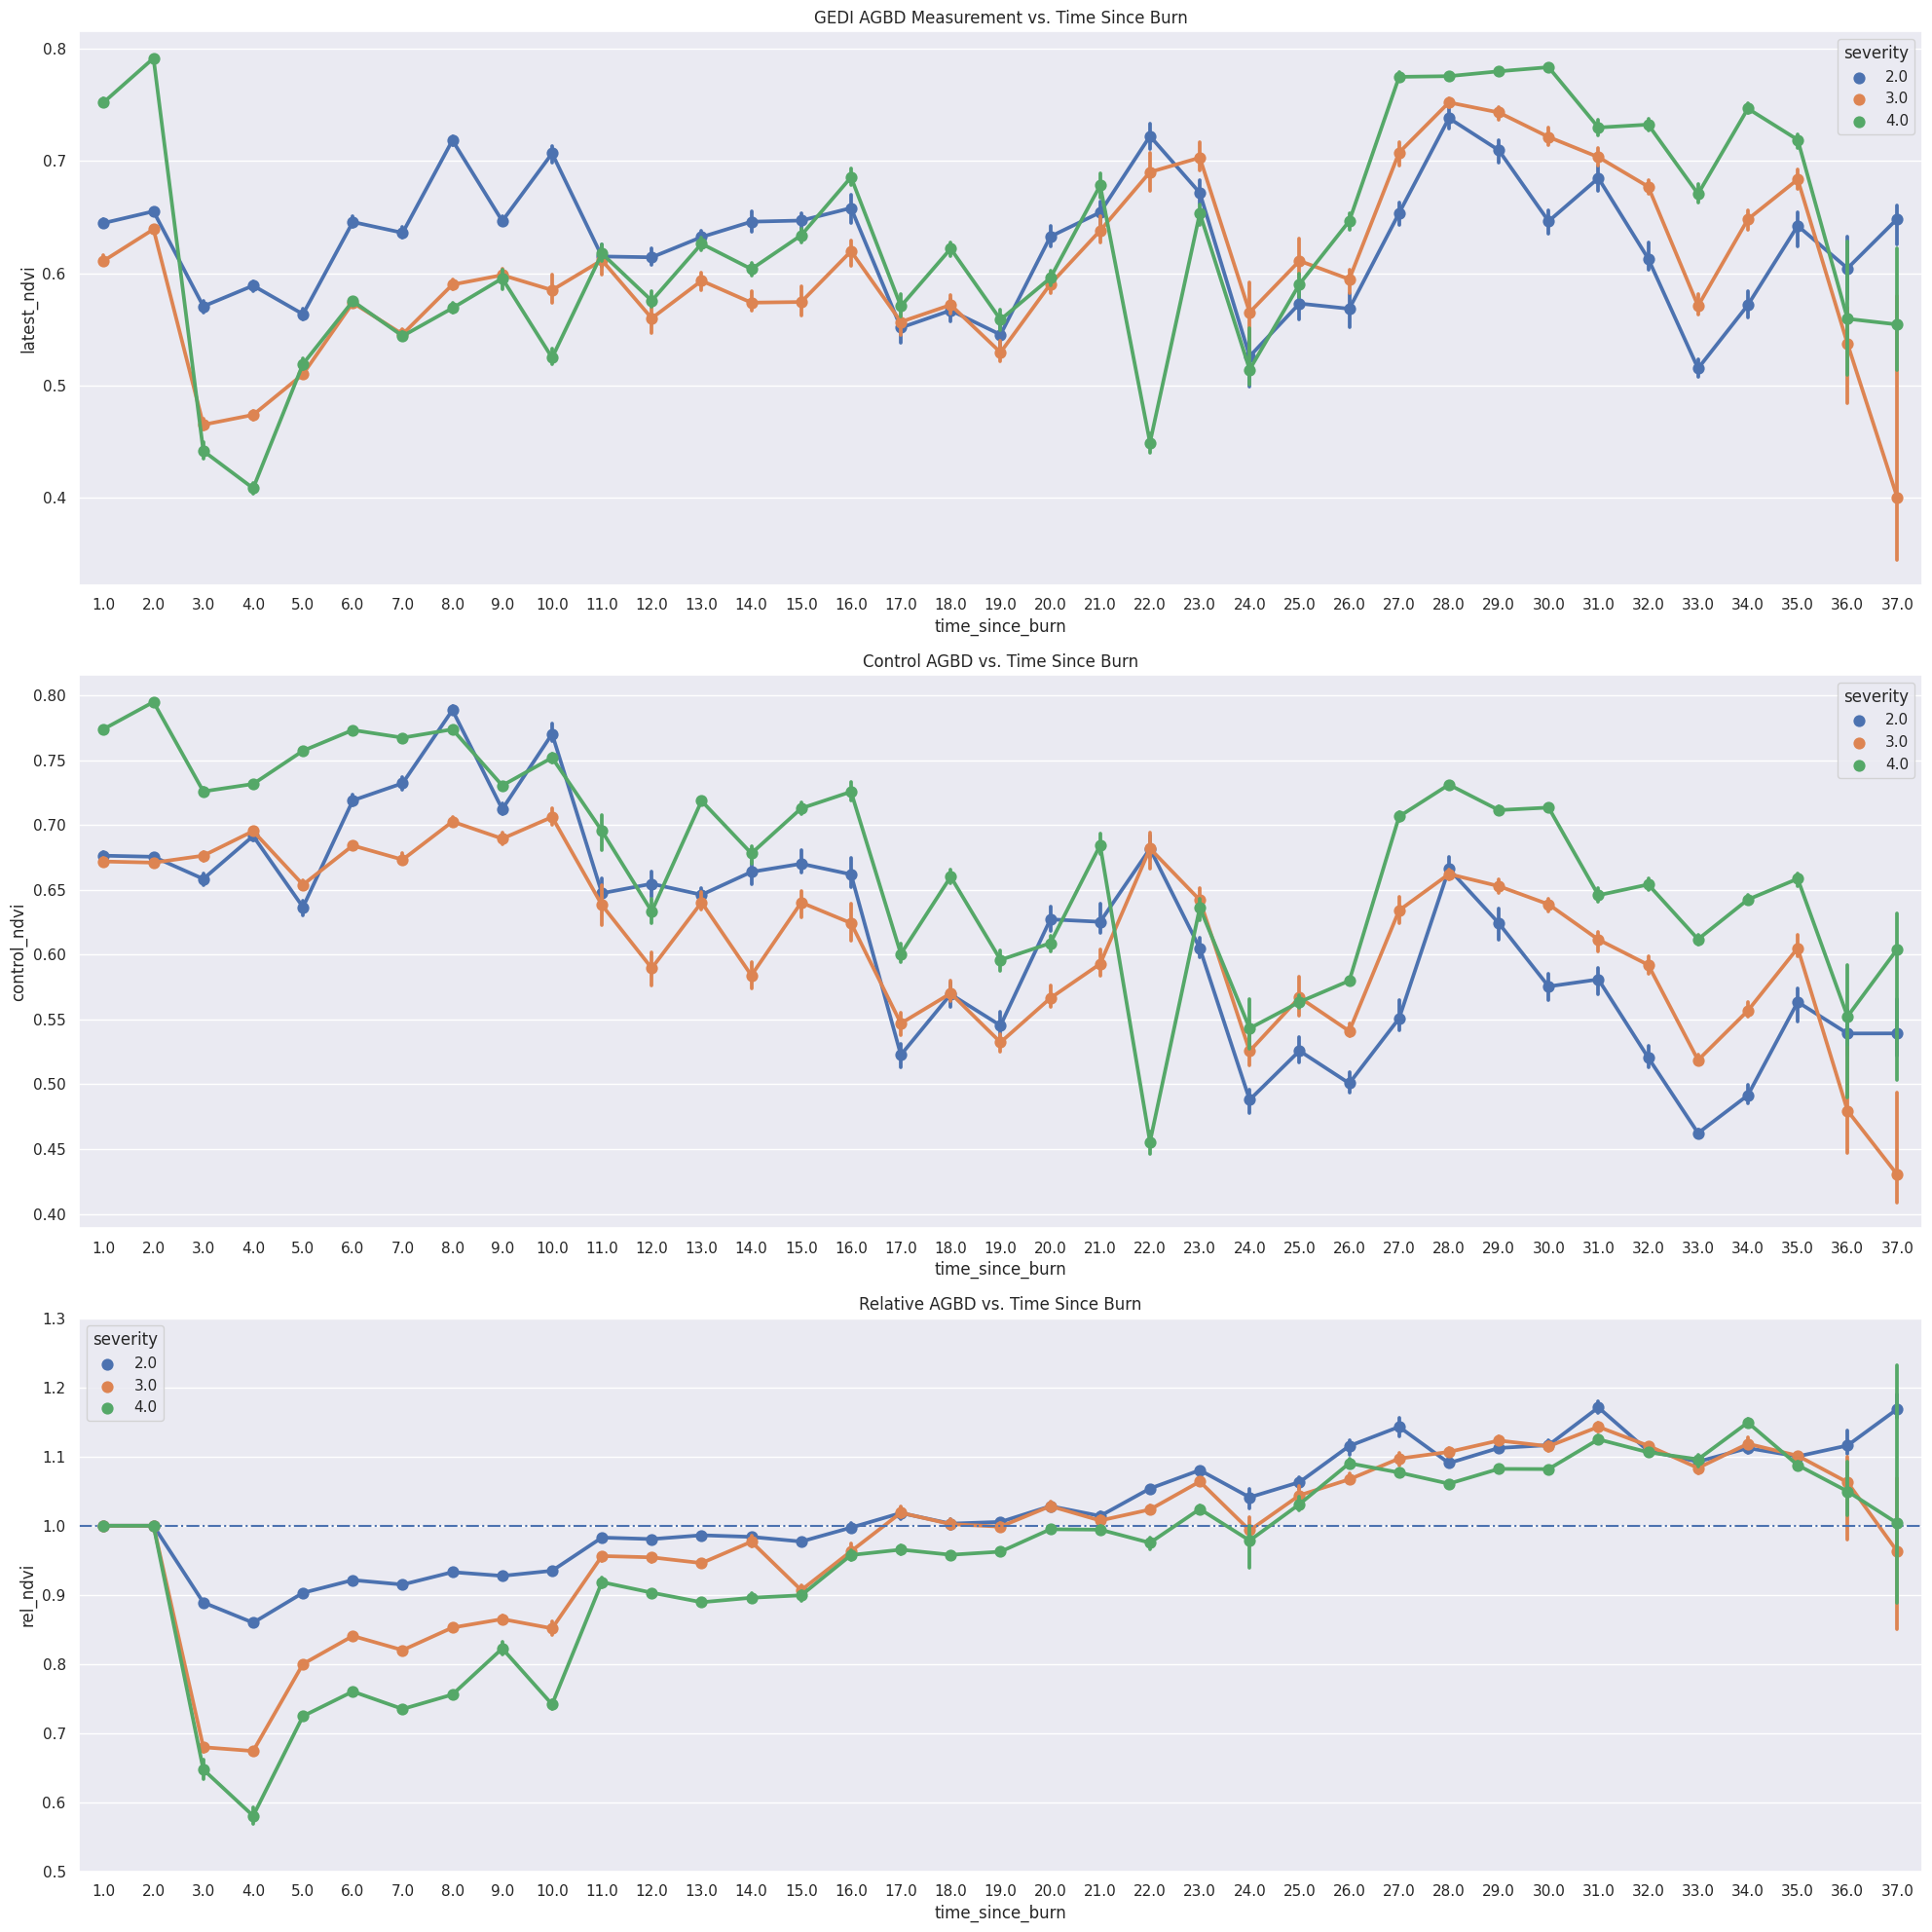

In [115]:
fig, ax = plt.subplots(3, 1, figsize=(20, 20))
sns.pointplot(gedi_recovery_2x2, x='time_since_burn', y='latest_ndvi', hue='severity', estimator='median', ax=ax[0])
sns.pointplot(gedi_recovery_2x2, x='time_since_burn', y='control_ndvi', hue='severity', estimator='median', ax=ax[1])
sns.pointplot(gedi_recovery_2x2, x='time_since_burn', y='rel_ndvi', hue='severity', estimator='median', ax=ax[2])
ax[2].axhline(y=1, linestyle="-.")

ax[0].set_title("GEDI AGBD Measurement vs. Time Since Burn")
ax[1].set_title("Control AGBD vs. Time Since Burn")
ax[2].set_title("Relative AGBD vs. Time Since Burn")

ax[2].set_ylim((0.5, 1.3))
fig.tight_layout()

### Let's try 200 nearest neighbour for NDVI and compare

In [108]:
from src.data import k_nn

In [110]:
nn_indeces, nn_distances = k_nn.nearest_neighbors(gedi_recovery_2x2, gedi_match_unburned, 200)

In [109]:
gedi_recovery_2x2.columns

Index(['index', 'shot_number', 'longitude', 'latitude', 'agbd',
       'agbd_pi_lower', 'agbd_pi_upper', 'agbd_se', 'beam_type', 'sensitivity',
       'pft_class', 'gedi_year', 'gedi_month', 'absolute_time', 'geometry',
       'severity', 'burn_year', 'burn_count', 'time_since_burn', 'elevation',
       'slope', 'aspect', 'soil', 'agbd_control', 'rel_agbd', 'latest_ndvi',
       'control_ndvi', 'rel_ndvi', 'agbd_div_ndvi', 'ndvi_div_agbd'],
      dtype='object')

In [111]:
gedi_recovery_2x2["ndvi_control_nn"] = np.apply_along_axis(
        lambda x: gedi_match_unburned.iloc[x].NDVI_mean.mean(), 1, nn_indeces)

In [116]:
gedi_recovery_2x2["agbd_control_nn"] = np.apply_along_axis(
        lambda x: gedi_match_unburned.iloc[x].agbd.mean(), 1, nn_indeces)

In [112]:
gedi_recovery_2x2["rel_ndvi_nn"] = gedi_recovery_2x2.latest_ndvi / gedi_recovery_2x2.ndvi_control_nn

In [117]:
gedi_recovery_2x2["rel_agbd_nn"] = gedi_recovery_2x2.agbd / gedi_recovery_2x2.agbd_control_nn

In [122]:
gedi_recovery_2x2["ndvi_control_ratio"] = gedi_recovery_2x2.ndvi_control_nn / gedi_recovery_2x2.control_ndvi

In [120]:
gedi_recovery_2x2.rel_ndvi

0         1.264812
1         1.274111
2         1.283064
3         1.291127
4         1.240449
            ...   
405942    1.000000
405943    1.000000
405944    1.000000
405945    1.000000
405946    1.000000
Name: rel_ndvi, Length: 405947, dtype: float64

In [123]:
gedi_recovery_2x2.rel_ndvi_nn * gedi_recovery_2x2.ndvi_control_ratio

0         1.264812
1         1.274111
2         1.283064
3         1.291127
4         1.240449
            ...   
405942    1.000000
405943    1.000000
405944    1.000000
405945    1.000000
405946    1.000000
Length: 405947, dtype: float64

In [125]:
save_pickle(f"{DATA_PATH}/ndvi_gedi.pkl", gedi_recovery_2x2)
save_pickle(f"{DATA_PATH}/ndvis.pkl", ndvis)

In [130]:
gedi_recovery_2x2["rel_agbd_derived"] = gedi_recovery_2x2.rel_agbd_nn * gedi_recovery_2x2.ndvi_control_ratio

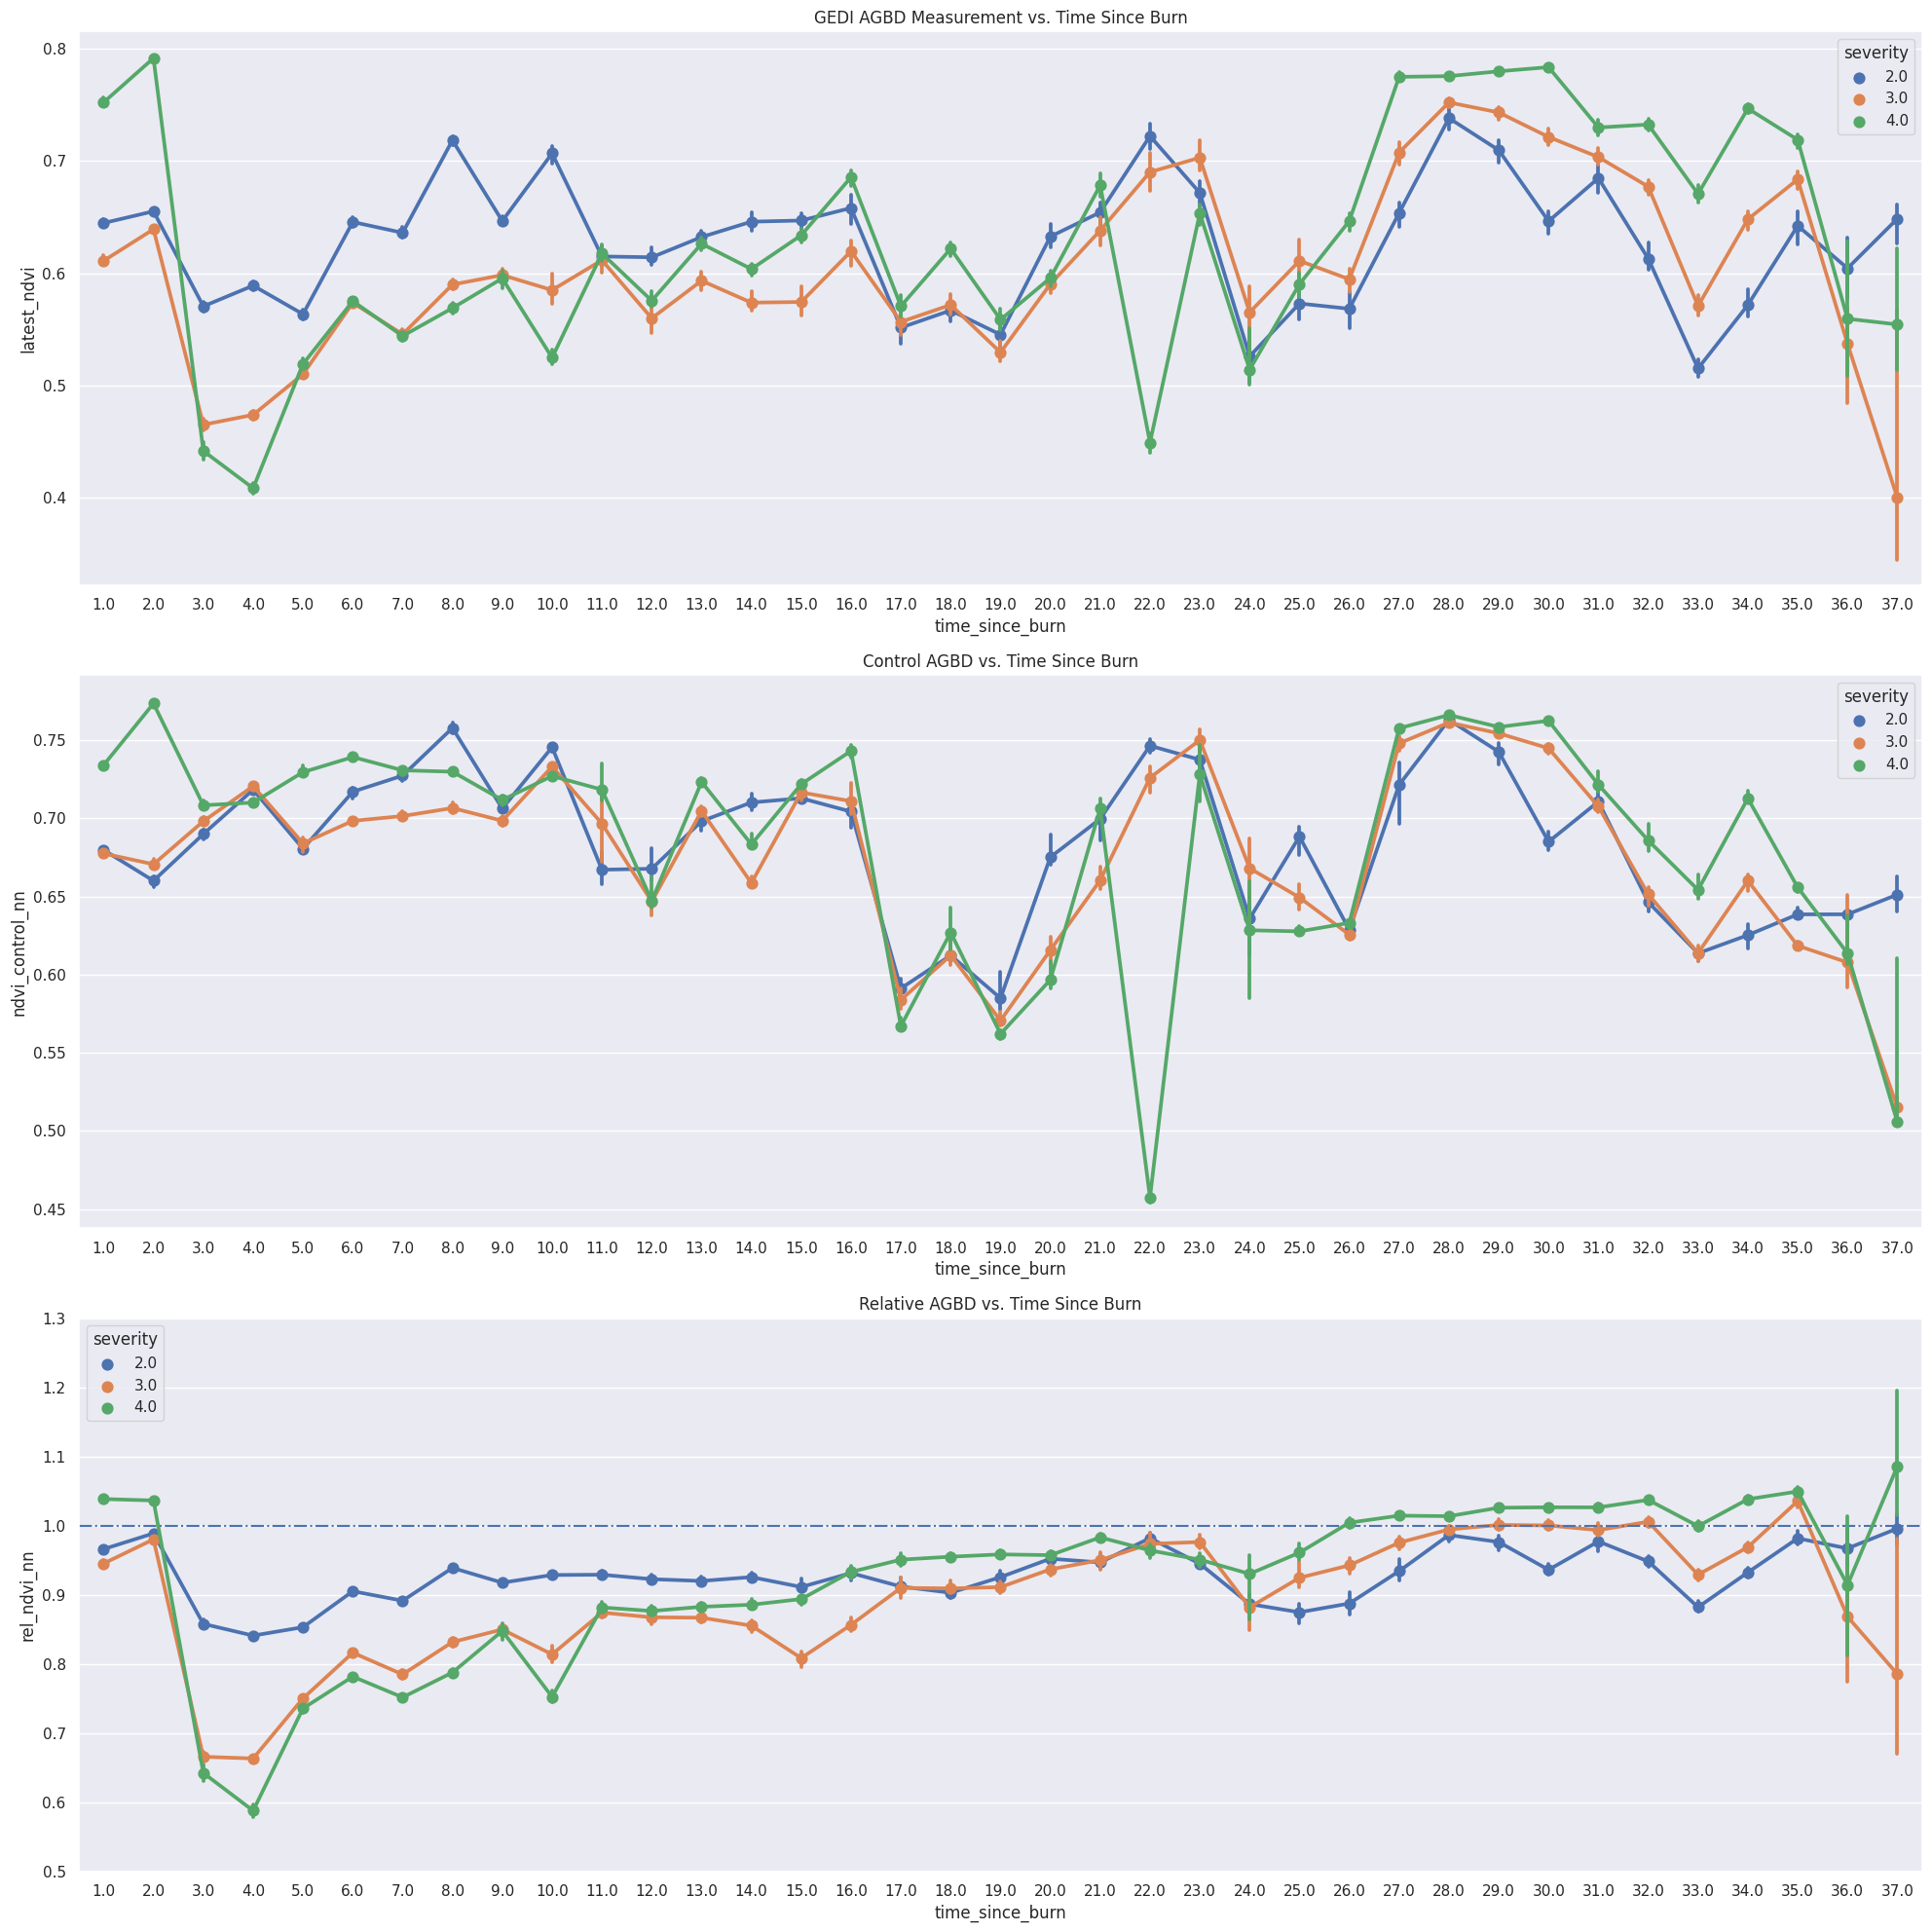

In [114]:
fig, ax = plt.subplots(3, 1, figsize=(20, 20))
sns.pointplot(gedi_recovery_2x2, x='time_since_burn', y='latest_ndvi', hue='severity', estimator='median', ax=ax[0])
sns.pointplot(gedi_recovery_2x2, x='time_since_burn', y='ndvi_control_nn', hue='severity', estimator='median', ax=ax[1])
sns.pointplot(gedi_recovery_2x2, x='time_since_burn', y='rel_ndvi_nn', hue='severity', estimator='median', ax=ax[2])
ax[2].axhline(y=1, linestyle="-.")

ax[0].set_title("GEDI AGBD Measurement vs. Time Since Burn")
ax[1].set_title("Control AGBD vs. Time Since Burn")
ax[2].set_title("Relative AGBD vs. Time Since Burn")

ax[2].set_ylim((0.5, 1.3))
fig.tight_layout()

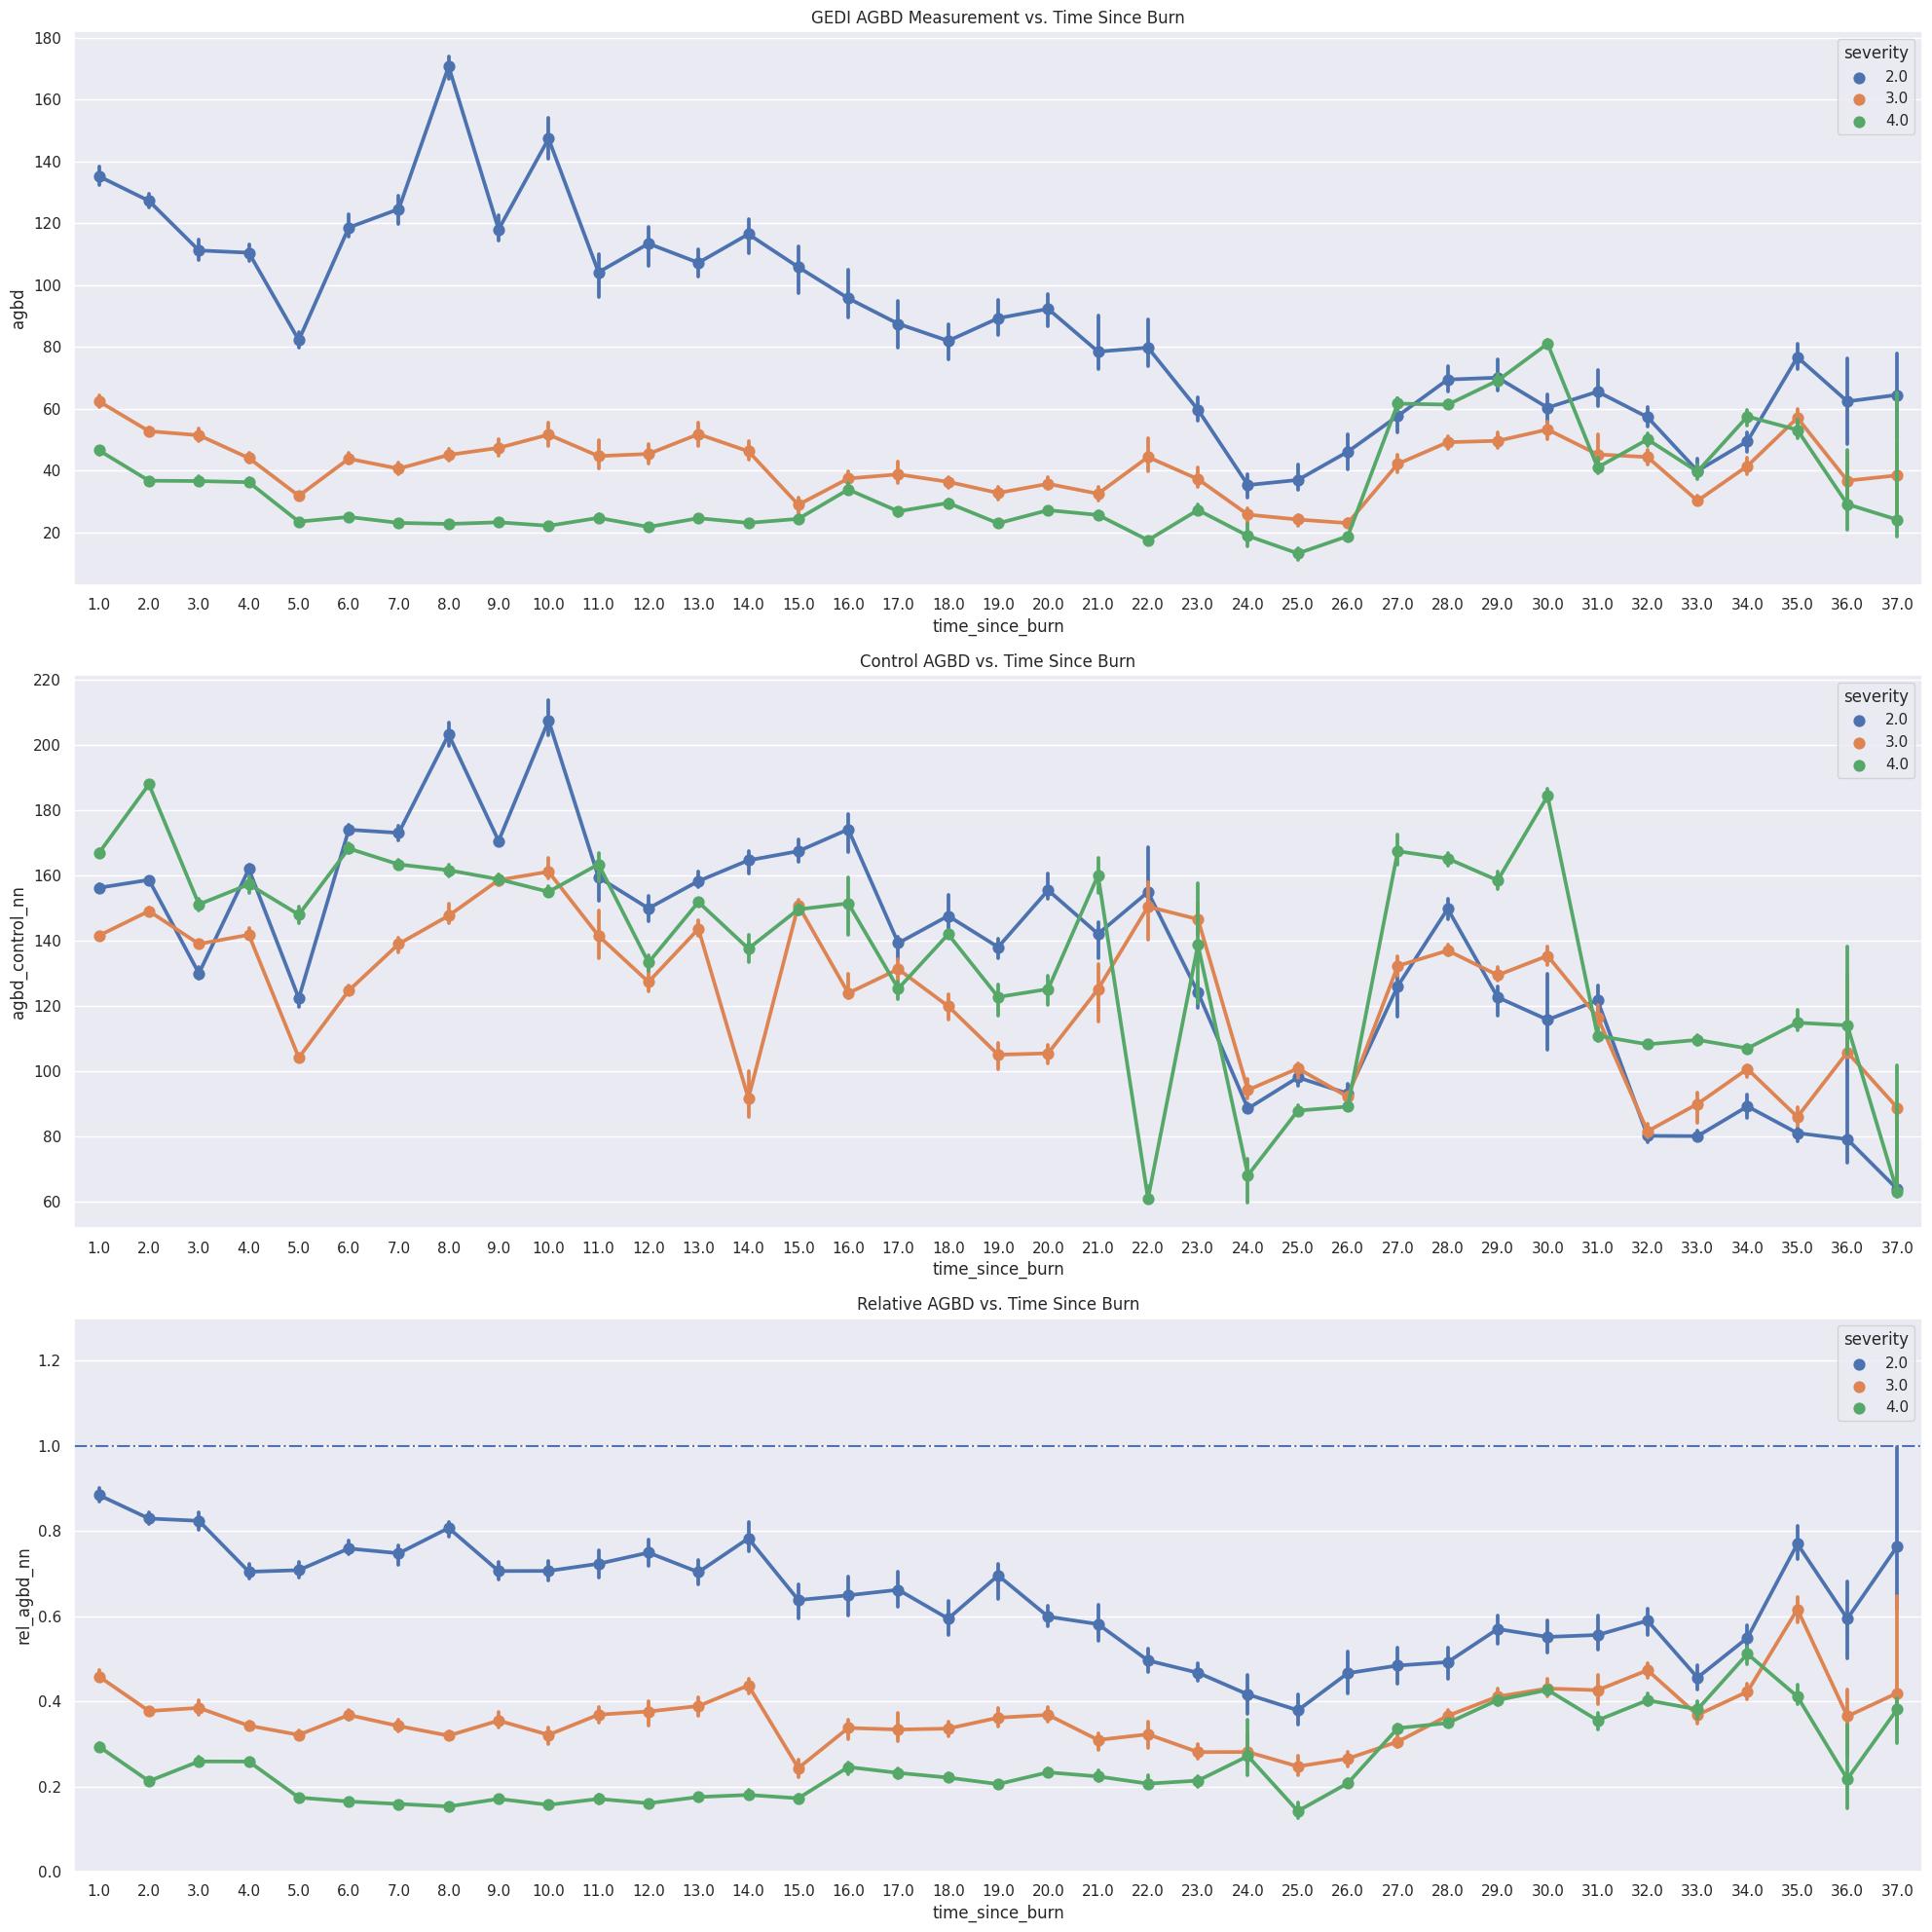

In [128]:
fig, ax = plt.subplots(3, 1, figsize=(20, 20))
sns.pointplot(gedi_recovery_2x2, x='time_since_burn', y='agbd', hue='severity', estimator='median', ax=ax[0])
sns.pointplot(gedi_recovery_2x2, x='time_since_burn', y='agbd_control_nn', hue='severity', estimator='median', ax=ax[1])
sns.pointplot(gedi_recovery_2x2, x='time_since_burn', y='rel_agbd_nn', hue='severity', estimator='median', ax=ax[2])
ax[2].axhline(y=1, linestyle="-.")

ax[0].set_title("GEDI AGBD Measurement vs. Time Since Burn")
ax[1].set_title("Control AGBD vs. Time Since Burn")
ax[2].set_title("Relative AGBD vs. Time Since Burn")

ax[2].set_ylim((0, 1.3))
fig.tight_layout()

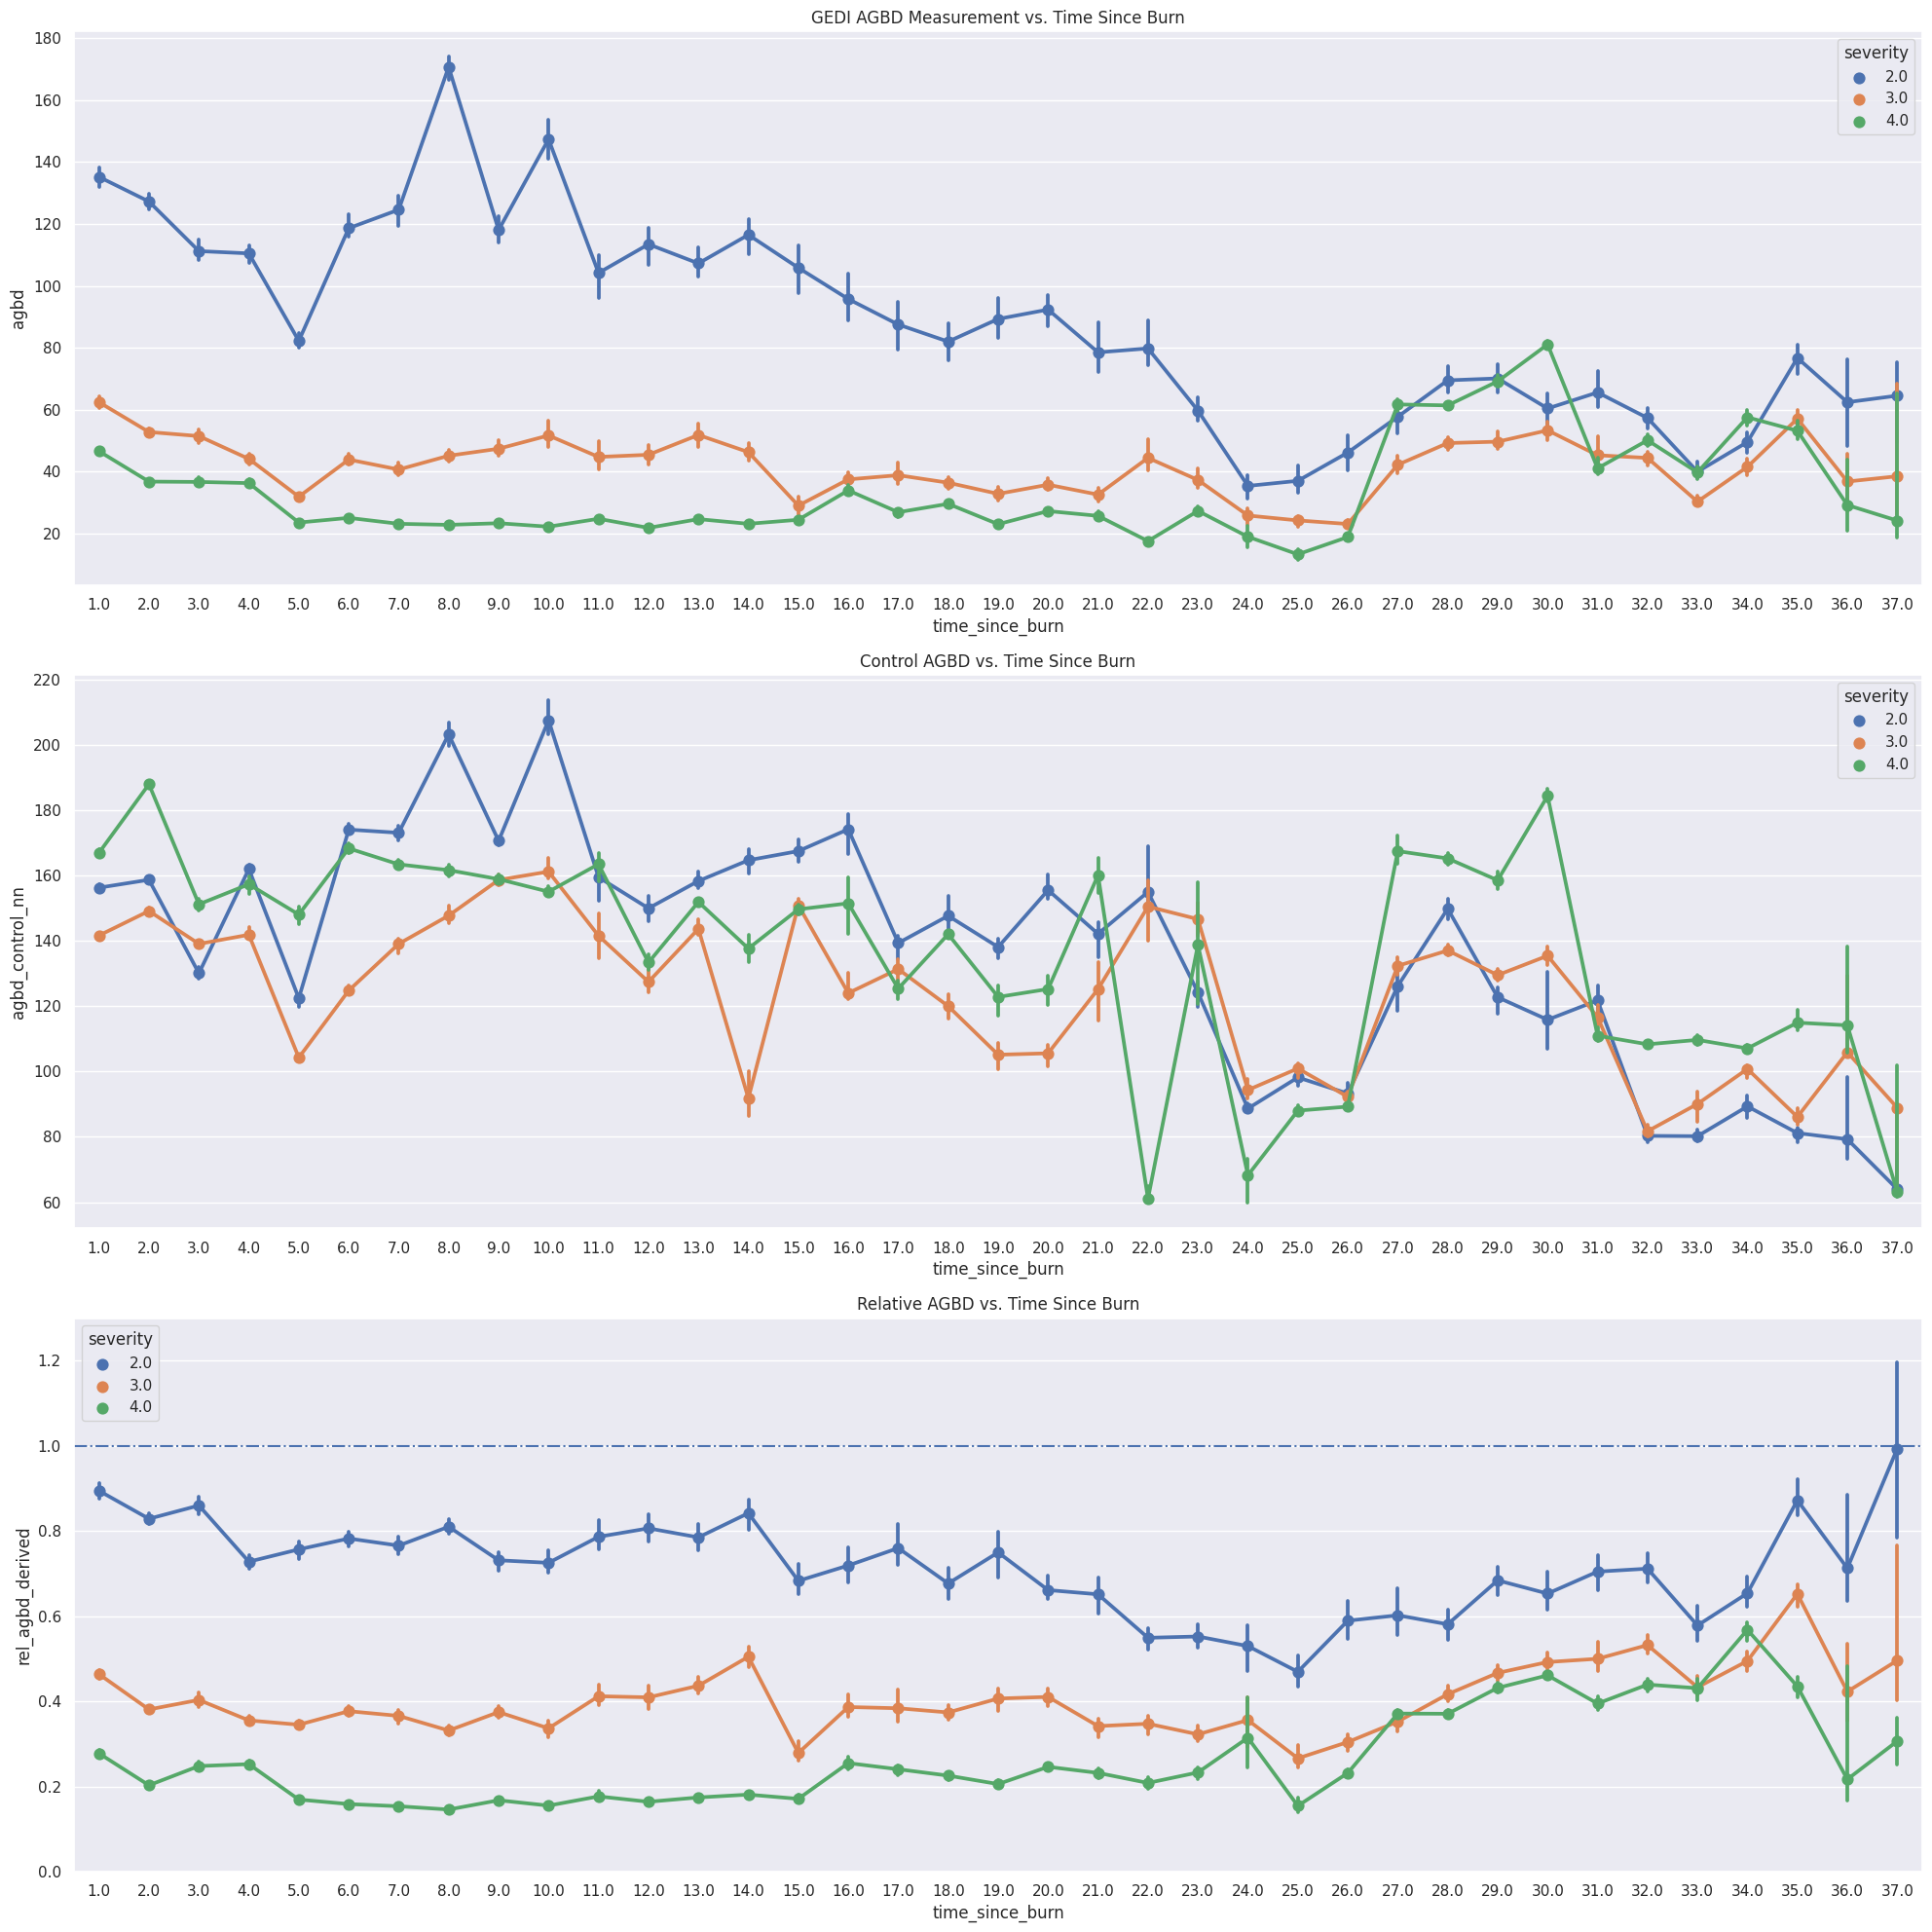

In [131]:
fig, ax = plt.subplots(3, 1, figsize=(20, 20))
sns.pointplot(gedi_recovery_2x2, x='time_since_burn', y='agbd', hue='severity', estimator='median', ax=ax[0])
sns.pointplot(gedi_recovery_2x2, x='time_since_burn', y='agbd_control_nn', hue='severity', estimator='median', ax=ax[1])
sns.pointplot(gedi_recovery_2x2, x='time_since_burn', y='rel_agbd_derived', hue='severity', estimator='median', ax=ax[2])
ax[2].axhline(y=1, linestyle="-.")

ax[0].set_title("GEDI AGBD Measurement vs. Time Since Burn")
ax[1].set_title("Control AGBD vs. Time Since Burn")
ax[2].set_title("Relative AGBD vs. Time Since Burn")

ax[2].set_ylim((0, 1.3))
fig.tight_layout()

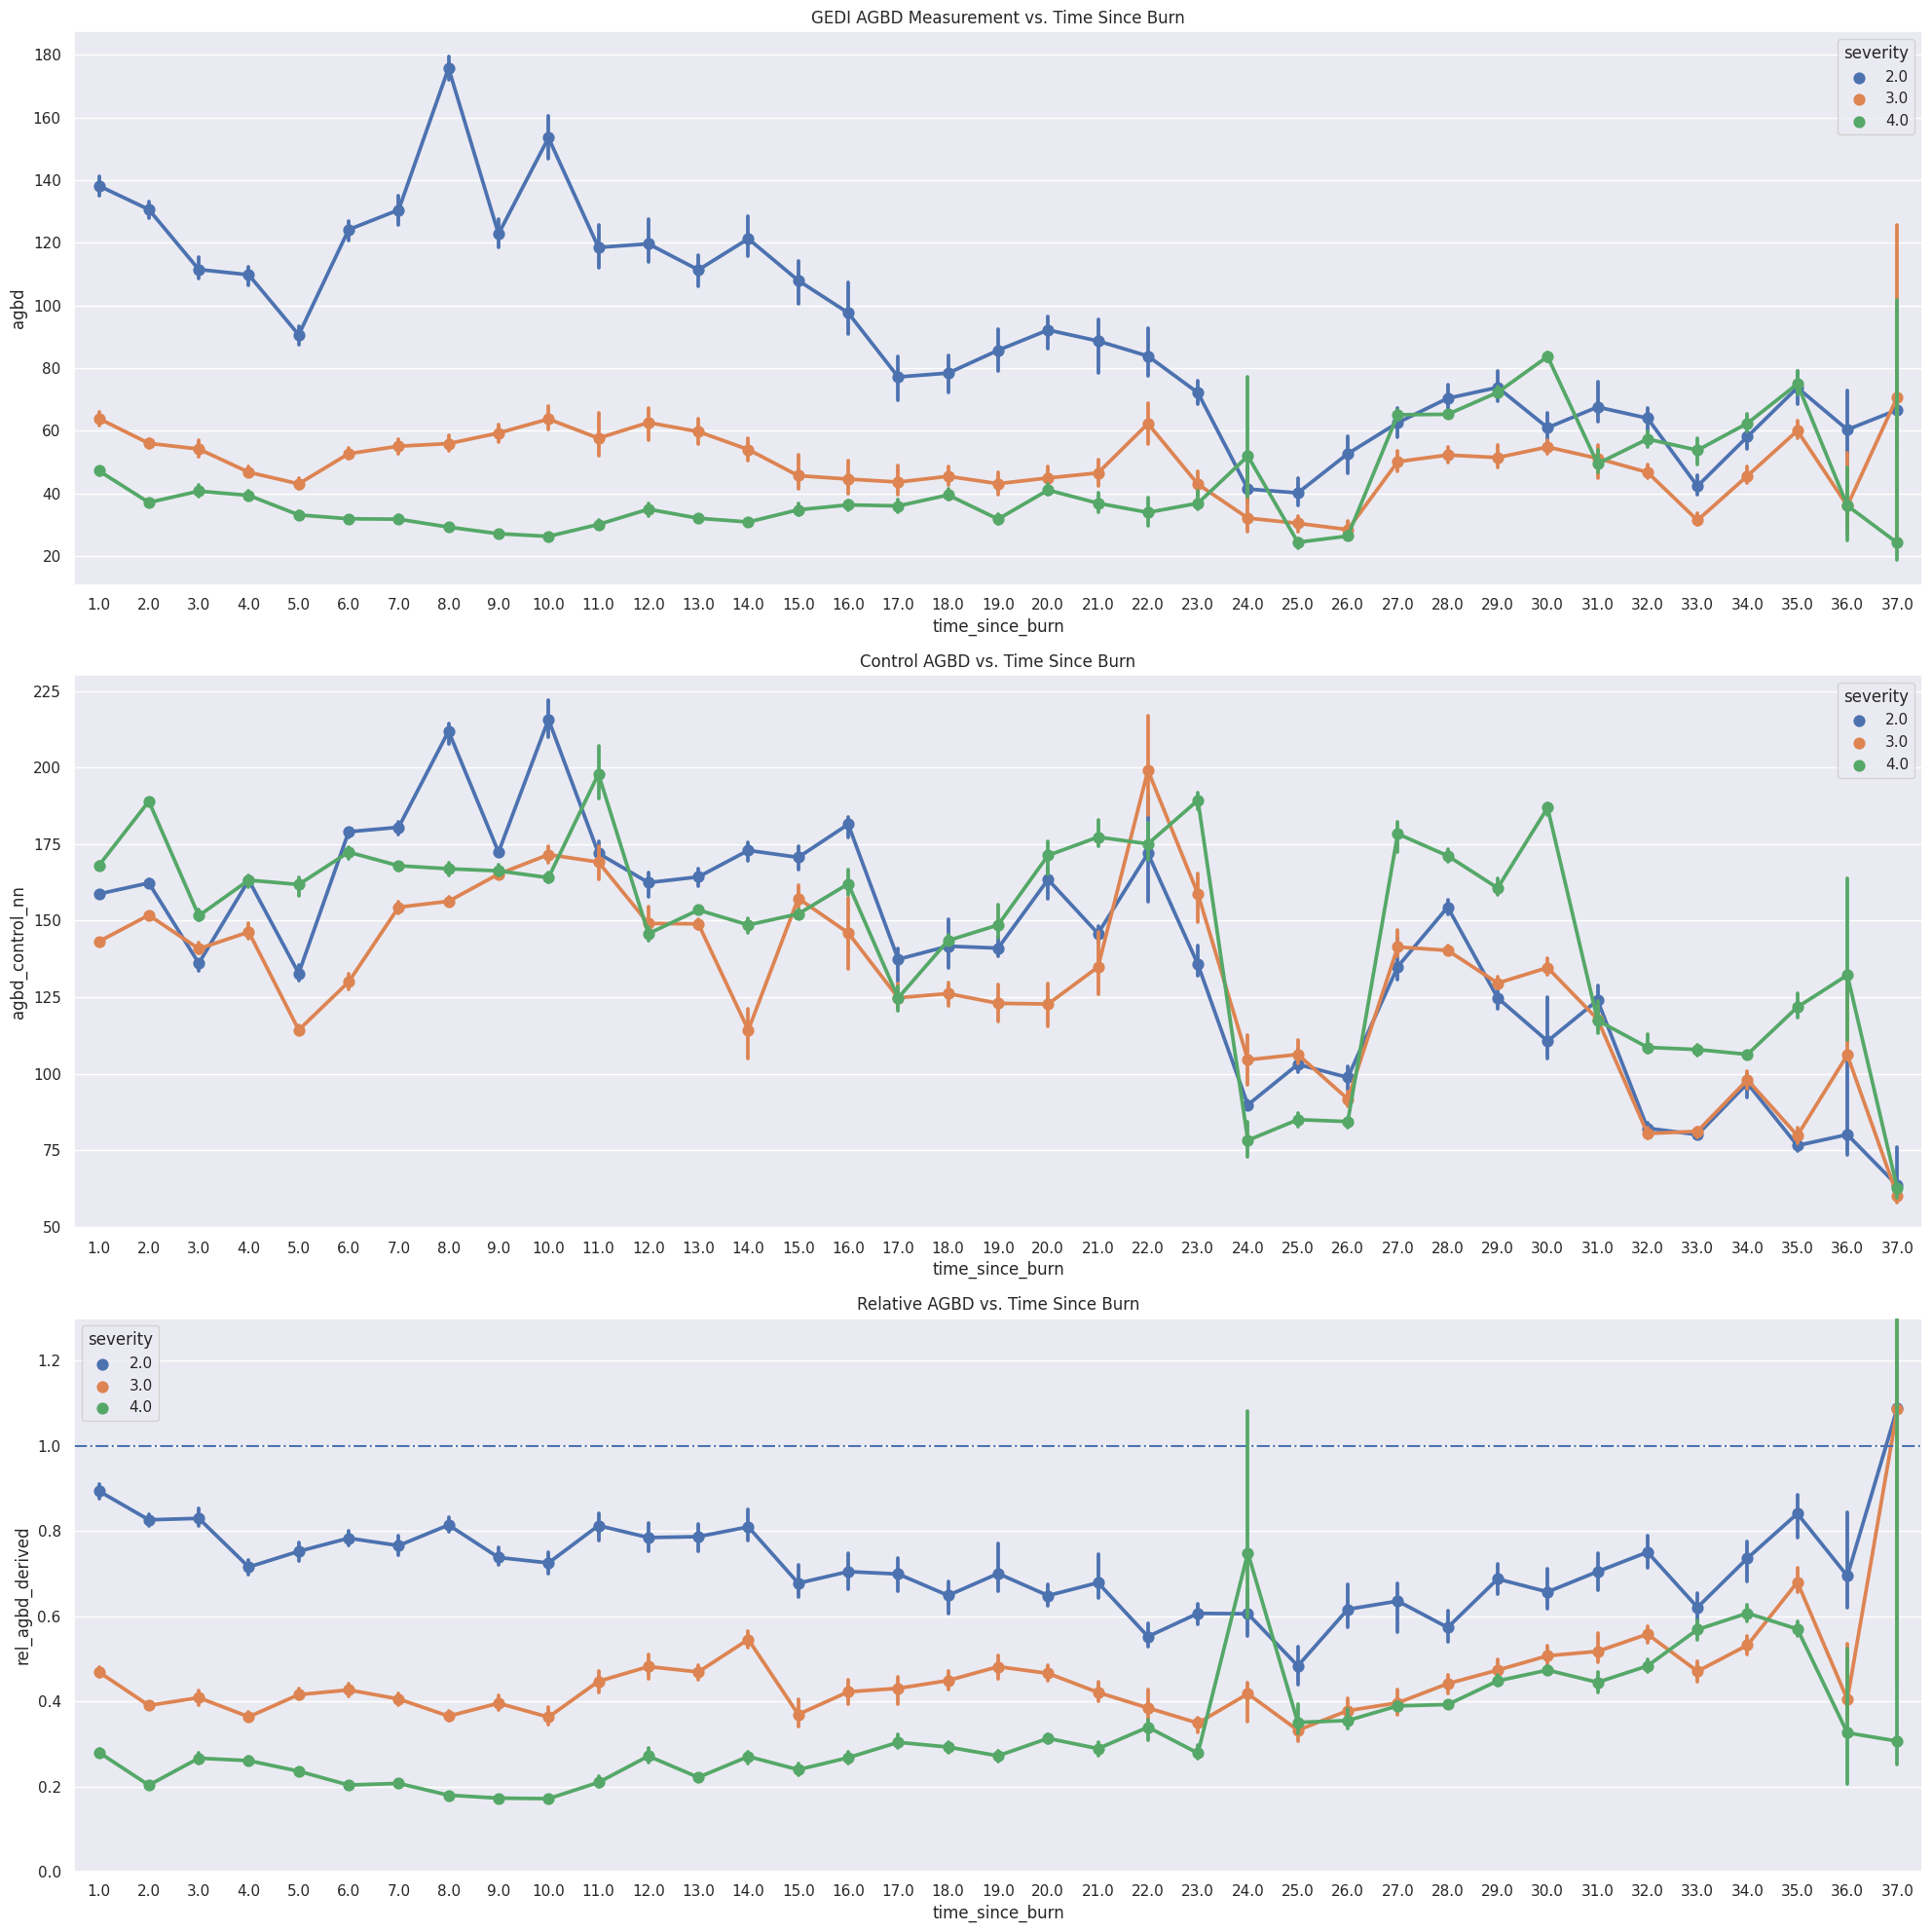

In [132]:
fig, ax = plt.subplots(3, 1, figsize=(20, 20))
sns.pointplot(gedi_recovery_2x2[gedi_recovery_2x2.pft_class==1], x='time_since_burn', y='agbd', hue='severity', estimator='median', ax=ax[0])
sns.pointplot(gedi_recovery_2x2[gedi_recovery_2x2.pft_class==1], x='time_since_burn', y='agbd_control_nn', hue='severity', estimator='median', ax=ax[1])
sns.pointplot(gedi_recovery_2x2[gedi_recovery_2x2.pft_class==1], x='time_since_burn', y='rel_agbd_derived', hue='severity', estimator='median', ax=ax[2])
ax[2].axhline(y=1, linestyle="-.")

ax[0].set_title("GEDI AGBD Measurement vs. Time Since Burn")
ax[1].set_title("Control AGBD vs. Time Since Burn")
ax[2].set_title("Relative AGBD vs. Time Since Burn")

ax[2].set_ylim((0, 1.3))
fig.tight_layout()

### Is NDVI of the past, similar to NDVI of the future?

In [133]:
gedi_match_unburned["NDVI_2020"] = gedi_match_unburned.NDVI_mean

In [134]:
# Match unburned with landsat 2020
raster = gedi_raster_matching.get_landsat_raster_sampler(1990)
gedi_match_unburned = gedi_raster_matching.sample_raster(raster, gedi_match_unburned, kernel=3)

/tmp/ipykernel_2061581/2508136390.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(gedi_match_unburned, x="NDVI_mean", y="NDVI_2020", ax=ax, palette="Set2")


<Axes: xlabel='NDVI_mean', ylabel='NDVI_2020'>

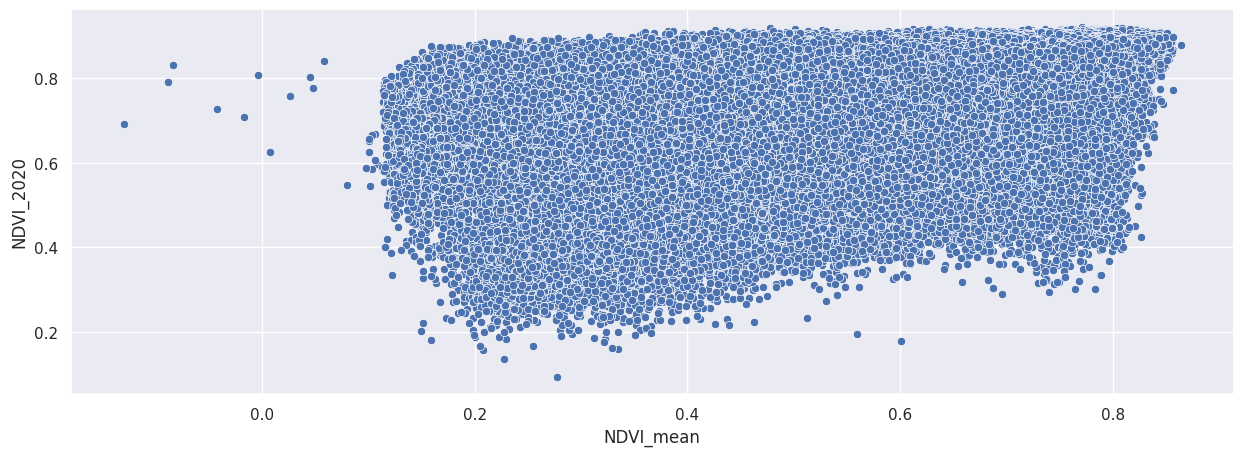

In [135]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.scatterplot(gedi_match_unburned, x="NDVI_mean", y="NDVI_2020", ax=ax, palette="Set2")

### Connecting to PAI

In [145]:
lala = gedi_recovery_2x2[gedi_recovery_2x2.pft_class == 1]

In [146]:
lala.columns

Index(['index', 'shot_number', 'longitude', 'latitude', 'agbd',
       'agbd_pi_lower', 'agbd_pi_upper', 'agbd_se', 'beam_type', 'sensitivity',
       'pft_class', 'gedi_year', 'gedi_month', 'absolute_time', 'geometry',
       'severity', 'burn_year', 'burn_count', 'time_since_burn', 'elevation',
       'slope', 'aspect', 'soil', 'agbd_control', 'rel_agbd', 'latest_ndvi',
       'control_ndvi', 'rel_ndvi', 'agbd_div_ndvi', 'ndvi_div_agbd',
       'ndvi_control_nn', 'rel_ndvi_nn', 'agbd_control_nn', 'rel_agbd_nn',
       'ndvi_control_ratio', 'rel_agbd_derived'],
      dtype='object')

In [144]:
gedi_l2b = pd.read_csv(f"{DATA_PATH}/sierras_gedi_l2b_shots.csv", index_col=0)

In [149]:
gedi_l2b_match = gedi_l2b[gedi_l2b.shot_number.isin(lala.shot_number)]

In [150]:
gedi_l2b_match = gedi_l2b_match[["shot_number", "pai"]]

In [151]:
gedi_l2b_match

,shot_number,pai
37073,52820500200082529,0.774422
69508,165410800300289775,2.151989
69509,165410800300289776,0.685239
69665,165410100300289618,1.311718
69672,165410100300289625,0.379540
...,...,...
27656622,156830600200451285,0.208037
27656623,156830600200451286,0.103860
27656625,156830600200451289,0.078656
27656637,156830800200084004,0.555083


In [ ]:
lala = 

In [ ]:
lala.join(gedi_l2b_match, on="")

### Load Data

In [2]:
gedi_recovery = load_pickle(f"{DATA_PATH}/ndvi_gedi.pkl")
ndvis = load_pickle(f"{DATA_PATH}/ndvis.pkl")

In [3]:
gedi_recovery

,index,shot_number,longitude,latitude,agbd,agbd_pi_lower,agbd_pi_upper,agbd_se,beam_type,sensitivity,...,control_ndvi,rel_ndvi,agbd_div_ndvi,ndvi_div_agbd,ndvi_control_nn,rel_ndvi_nn,agbd_control_nn,rel_agbd_nn,ndvi_control_ratio,rel_agbd_derived
0,68024,73111100200078593,-120.746781,38.169353,188.598526,68.062080,369.264771,11.101941,full,0.987382,...,0.568421,1.264812,331.793769,0.003014,0.651186,1.104055,63.814523,2.955417,1.145606,73.106292
1,68147,225020800200125443,-120.741764,38.159710,49.447220,2.394614,156.657501,11.107099,full,0.984889,...,0.587675,1.274111,84.140430,0.011885,0.651286,1.149668,63.196434,0.782437,1.108242,70.036953
2,68233,42640600300521207,-120.750616,38.172525,27.992105,5.854515,66.616653,2.982341,full,0.972790,...,0.572759,1.283064,48.872385,0.020461,0.636436,1.154691,54.076991,0.517634,1.111176,60.089038
3,68234,42640600300521208,-120.750114,38.172192,83.234764,38.882565,144.264801,3.016872,full,0.974146,...,0.587906,1.291127,141.578456,0.007063,0.637521,1.190645,54.438319,1.528974,1.084393,59.032538
4,68278,20150200200125415,-120.747949,38.168811,167.028885,55.373684,338.802307,11.099805,coverage,0.981629,...,0.506719,1.240449,329.628172,0.003034,0.651924,0.964161,64.103599,2.605609,1.286558,82.473008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405942,27618965,225630800200085762,-119.550515,38.565973,19.979471,-9999.000000,99.098244,11.109340,full,0.965883,...,0.451418,1.000000,44.259347,0.022594,0.536849,0.840866,79.050233,0.252744,1.189249,94.010448
405943,27618967,225630800200085764,-119.549511,38.566621,20.807606,-9999.000000,100.928558,11.108585,full,0.968726,...,0.563058,1.000000,36.954625,0.027060,0.536849,1.048821,79.050233,0.263220,0.953452,75.370571
405944,27618975,225631100200080331,-119.554363,38.556271,131.316925,35.723694,287.024231,11.099050,full,0.994654,...,0.502332,1.000000,261.414785,0.003825,0.537938,0.933810,81.154100,1.618118,1.070882,86.906440
405945,27624050,156220200200085334,-119.406297,38.528133,31.825970,0.024733,123.779739,11.106153,coverage,0.951131,...,0.462731,1.000000,68.778526,0.014539,0.512999,0.902013,57.710534,0.551476,1.108632,63.979736


In [4]:
ndvis.shape

(405947, 36)

In [ ]:
control_ndvi = np.empty(gedi_recovery_2x2.shape[0])
control_index = (gedi_recovery_2x2.burn_year - 1985).values.astype(int)
for i in range(gedi_recovery_2x2.shape[0]):
    control_ndvi[i] = ndvis[i, control_index[i]]
gedi_recovery_2x2["control_ndvi"] = control_ndvi

In [8]:
control_index = (gedi_recovery_2x2.burn_year - 1985).values.astype(int)

In [10]:
control_index - 1

array([-1, -1, -1, ..., 34, 34, 34])

In [11]:
ndvis.shape

(405947, 36)

In [17]:
all_ndvis = np.empty((gedi_recovery_2x2.shape[0], 45))
control_index = (gedi_recovery_2x2.burn_year - 1985).values.astype(int)
for i in range(gedi_recovery_2x2.shape[0]):
    for j in range(-10, 35):
        recovery_index = control_index[i] + j
        if recovery_index in range(0, 36):
            all_ndvis[i, j + 10] = ndvis[i, recovery_index]
        else:
            all_ndvis[i, j + 10] = None
#gedi_recovery_2x2["control_ndvi"] = control_ndvi

In [20]:
ndvis_df = pd.DataFrame(all_ndvis, columns=[str(x) for x in range(-10, 35)])
ndvis_df

,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,...,25,26,27,28,29,30,31,32,33,34
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.569583,0.662150,0.654849,0.595411,0.644008,0.582611,0.636357,0.632610,0.675366,0.664085
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.622541,0.693751,0.694441,0.632157,0.694591,0.638106,0.677997,0.685623,0.718585,0.691538
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.593550,0.696997,0.682389,0.627655,0.665395,0.581009,0.649598,0.642705,0.692194,0.675550
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.612236,0.700114,0.691291,0.643578,0.681679,0.608909,0.685482,0.681916,0.718076,0.705058
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.501844,0.571775,0.589922,0.496090,0.529609,0.494940,0.538704,0.525096,0.575220,0.549411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405942,0.390942,0.423073,0.438944,0.397288,0.454312,0.442310,0.409898,0.418196,0.449566,0.434038,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
405943,0.450265,0.512030,0.540078,0.476451,0.525902,0.511935,0.475957,0.526999,0.561465,0.533854,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
405944,0.423237,0.448149,0.474085,0.430515,0.492061,0.479251,0.464917,0.479695,0.513713,0.491255,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
405945,0.397372,0.423473,0.427977,0.389965,0.451721,0.431205,0.427321,0.449603,0.460166,0.439250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
gedi_ndvi = gedi_recovery.join(ndvis_df)

In [37]:
gedi_ndvi = gedi_ndvi[gedi_ndvi.pft_class == 1]

In [38]:
new_df = pd.melt(gedi_ndvi, id_vars=["severity", "burn_year"], value_vars=[str(x) for x in range(-10, 35)])
new_df

#new_df['severity'] = severity
#new_df['date_since'] = date_since

,severity,burn_year,variable,value
0,2.0,1985.0,-10,NaN
1,2.0,1985.0,-10,NaN
2,2.0,1985.0,-10,NaN
3,2.0,1985.0,-10,NaN
4,3.0,1985.0,-10,NaN
...,...,...,...,...
15033235,2.0,2020.0,34,NaN
15033236,3.0,2020.0,34,NaN
15033237,2.0,2020.0,34,NaN
15033238,4.0,2020.0,34,NaN


<Axes: xlabel='variable', ylabel='value'>

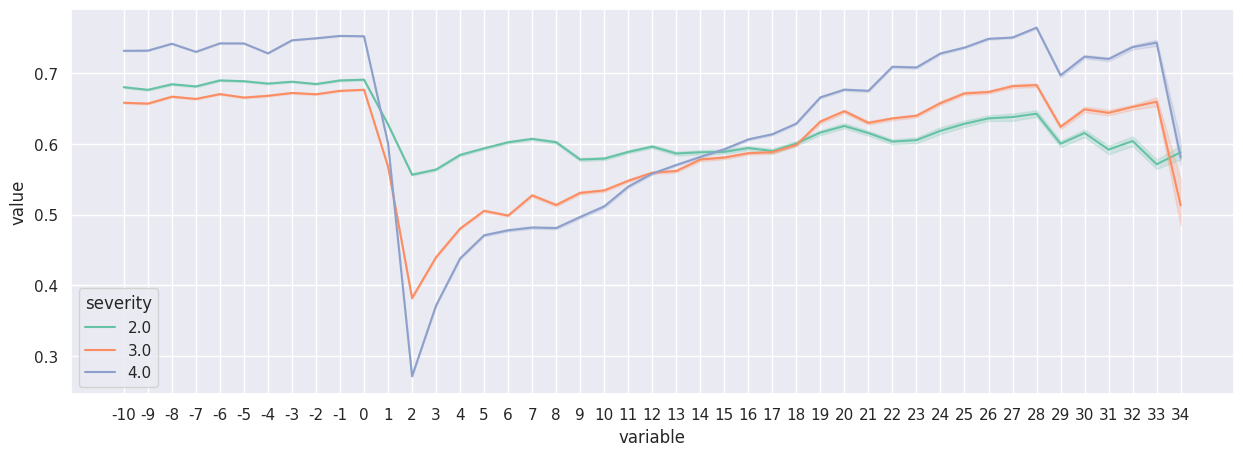

In [39]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.lineplot(new_df, x="variable", y="value", hue="severity", ax=ax, palette="Set2", estimator="median")

<Axes: xlabel='variable', ylabel='value'>

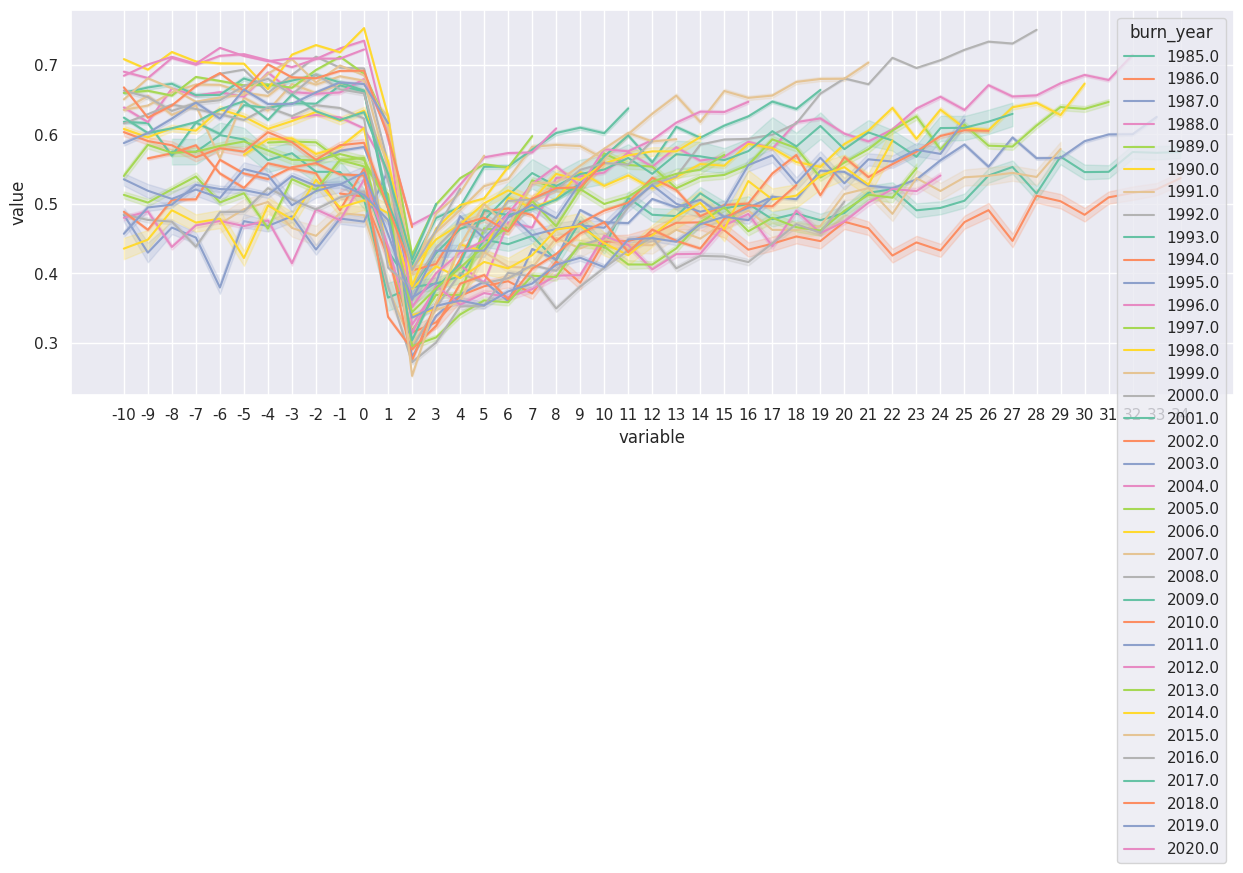

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.lineplot(new_df[new_df], x="variable", y="value", hue="burn_year", ax=ax, palette="Set2")

<Axes: xlabel='variable', ylabel='value'>

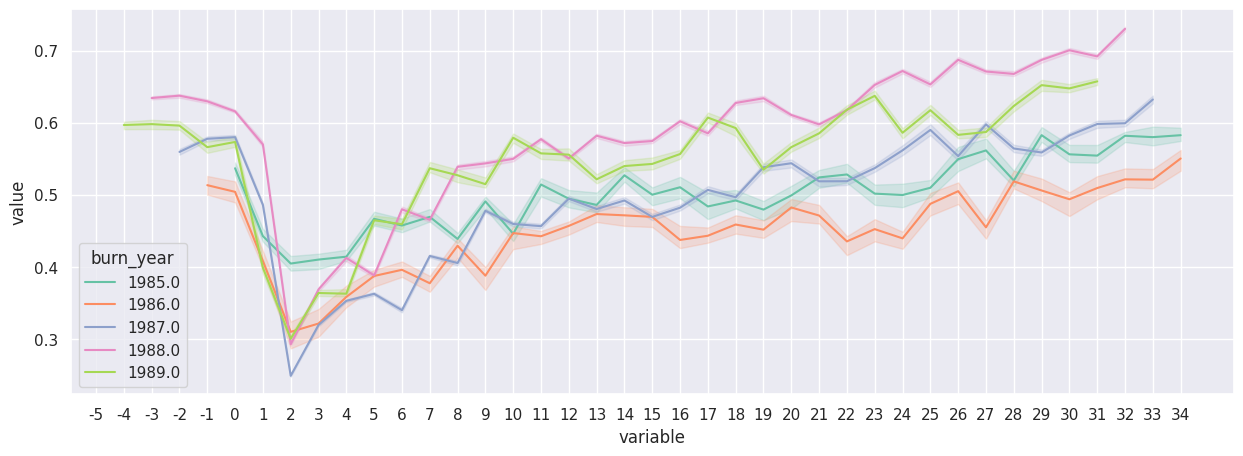

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.lineplot(new_df[new_df.burn_year.isin(range(1985, 1990))], x="variable", y="value", hue="burn_year", ax=ax, palette="Set2", estimator="median")

<Axes: xlabel='time_since_burn', ylabel='rel_agbd'>

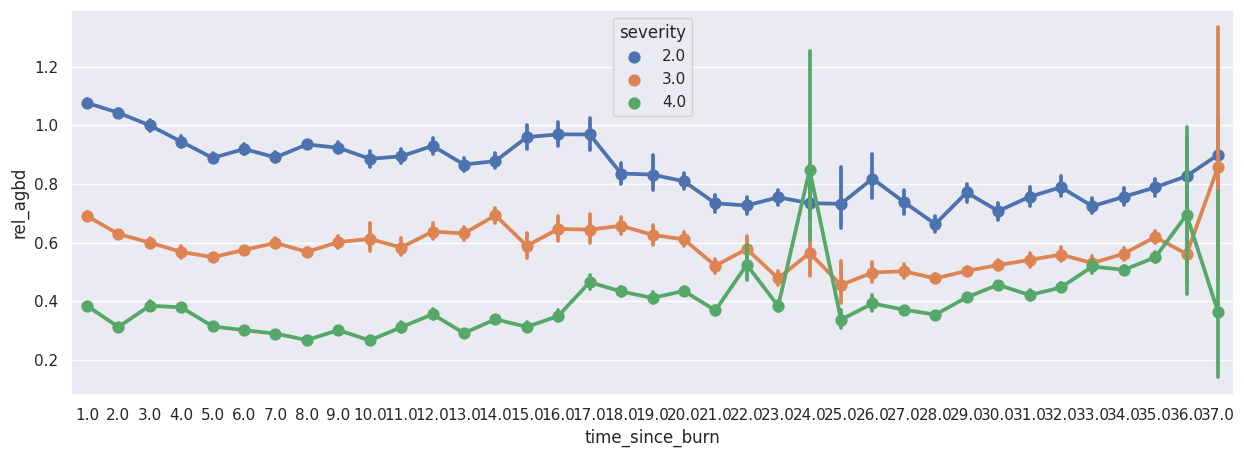

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.pointplot(gedi_recovery_2x2[gedi_recovery_2x2.pft_class == 1], x="time_since_burn", y="rel_agbd", hue="severity", ax=ax)

<Axes: xlabel='slope', ylabel='Count'>

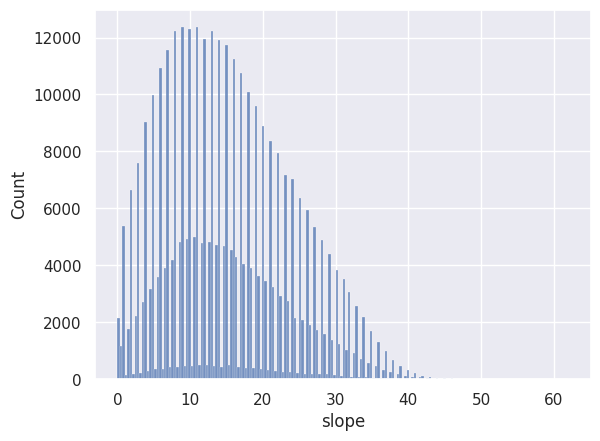

In [41]:
sns.histplot(gedi_recovery_2x2, x="slope")

<Axes: xlabel='time_since_burn', ylabel='rel_agbd'>

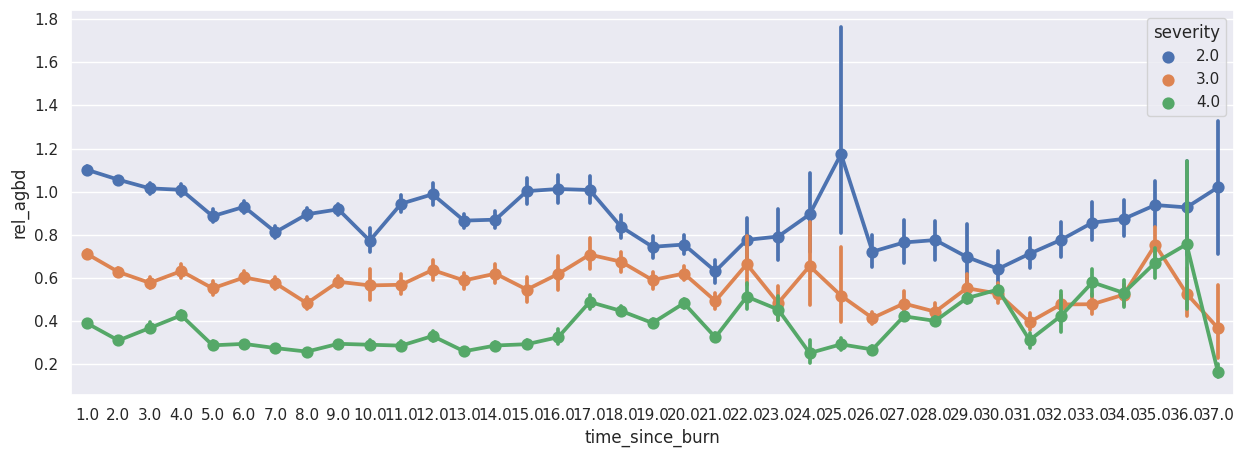

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.pointplot(gedi_recovery_2x2[(gedi_recovery_2x2.pft_class == 1) & (gedi_recovery_2x2.elevation >1500)], x="time_since_burn", y="rel_agbd", hue="severity", ax=ax)